# All final plots and analyses for figure 3 --> new

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math
import scipy.stats as stats
import warnings
from statannotations.Annotator import Annotator
warnings.filterwarnings('ignore')
import joblib

### Load and process Baghela metadate

In [2]:
sraTable = pd.read_csv('../../data/bulk_data/Baghela_2020/Metadata_Baghela.csv', index_col=0)
anno = sraTable
anno['disease_group'].value_counts()

disease_group
Sepsis Survived    293
Sepsis Died         52
Healthy Control     44
Name: count, dtype: int64

In [3]:
# Load bulks
bulks = pd.read_csv('../../data/bulk_data/Baghela_2020/TPM_data_Baghela.csv', index_col=0)
bulks

,DPM1,SCYL3,FIRRM,FGR,CFH,FUCA2,GCLC,NFYA,STPG1,NIPAL3,...,TRBV6-3,H2BC6-AS1,LOC105372480,RN7SK,MPHOSPH10P3,CNTNAP3C,PET100P1,GPR141BP,LOC100996792,LINC02009
geo_accesion,,,,,,,,,,,,,,,,,,,,,
GSM5609238,4.61,3.94,0.52,159.66,0.99,6.12,7.40,10.56,0.43,6.40,...,4.00,0.70,0.22,8.24,0.00,1.27,0.00,0.00,0.41,0.09
GSM5609334,27.62,7.74,1.80,403.36,1.48,9.35,11.41,17.77,1.60,13.47,...,11.76,0.93,0.28,8.95,0.43,2.68,2.15,0.11,0.00,0.20
GSM5609219,17.90,6.13,0.99,190.06,0.41,7.67,9.31,12.42,0.60,8.90,...,12.95,0.13,0.31,6.79,0.00,1.06,0.00,0.27,0.45,0.00
GSM5609245,19.85,7.40,3.06,195.43,0.67,10.99,13.81,15.31,0.79,13.14,...,12.21,0.30,0.38,3.36,0.00,0.05,0.00,0.00,0.20,0.00
GSM5609213,5.00,2.50,0.97,123.78,0.19,5.23,3.10,4.39,0.51,5.69,...,2.56,0.35,0.08,11.36,0.09,0.41,0.00,0.07,0.04,0.13
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
GSM5609298,24.80,9.59,0.82,1509.95,1.59,7.37,3.37,20.09,0.54,4.63,...,0.00,2.34,0.47,60.85,2.14,3.97,0.00,0.55,0.28,0.08
GSM5609114,6.05,1.71,0.28,218.38,0.51,3.48,0.69,2.13,0.07,0.58,...,0.26,0.68,0.20,21.01,0.00,0.25,1.30,0.39,0.66,0.02
GSM5609322,55.55,8.69,2.88,408.55,2.73,17.97,18.07,15.72,0.65,6.40,...,2.44,8.11,0.53,51.13,1.05,0.38,0.00,2.50,0.11,9.48


In [4]:
# Load predictions
pred = pd.read_csv('../../grood_runs/GrooD_Hao_Baghela/intersect_mRNA/inference/Predicted_cell_type_proportions.csv', index_col=0)
pred

,B cells,CD4 T cells,CD8 T cells,DC,Monocytes,NK cells,Tregs
GSM5609238,0.021858,0.150379,0.045417,0.009398,0.125937,0.043126,0.038134
GSM5609334,0.072355,0.347783,0.064748,0.030755,0.260759,0.101801,0.058758
GSM5609219,0.032436,0.137427,0.119684,0.021985,0.132971,0.044027,0.036564
GSM5609245,0.065441,0.321514,0.227009,0.021999,0.185102,0.060845,0.033397
GSM5609213,0.037557,0.101736,0.038850,0.007259,0.075908,0.069258,0.034207
...,...,...,...,...,...,...,...
GSM5609298,0.042597,0.047385,0.016017,0.008042,0.300368,0.053215,0.022267
GSM5609114,0.010133,0.046002,0.023565,0.006194,0.151453,0.025792,0.026272
GSM5609322,0.037496,0.071949,0.035800,0.026001,0.359700,0.045701,0.016956
GSM5609076,0.004978,0.055703,0.215500,0.006930,0.249249,0.031785,0.027004


In [5]:
def props_with_test(df, metadata, condition, pse):
    metadata.index = metadata['geo_accesion']
    celltypes = df.columns.tolist()
    df = df.copy()

    # CLR normalization of the data
    pse = pse
    props_pse = df.replace(0, pse)
    logs = np.log(props_pse)
    clr = logs.sub(logs.mean(axis=1), axis=0)
    clr = pd.DataFrame(clr, columns=celltypes, index=df.index.tolist())

    #return clr

    clr[condition] = metadata.loc[df.index.tolist(), condition]
    df = clr

    n = len(celltypes)
    rows = math.floor(math.sqrt(n))
    cols = math.ceil(n/rows)

    fig, axes = plt.subplots(rows, cols, figsize=(cols * 4, rows * 4))
    axes = np.array(axes) # axes must be an iterable array

    axes = axes.flatten() # flatten in case of multi-dimensionality

    for i, celltype in enumerate(celltypes):
        col_selection = [condition, str(celltype)]
        pred_new = df.copy()
        pred_new = pred_new[col_selection]
        pred_new['SampleID'] = pred_new.index.tolist()
        df_plot = pred_new.melt(id_vars=[condition, 'SampleID'])

        p = sns.boxplot(data=df_plot, x = condition, y = "value", hue = condition, ax=axes[i])
        p.set_xticklabels(p.get_xticklabels(), rotation=45, horizontalalignment='right')

        # define pairs for comparison
        pairs = [("Healthy Control", "Sepsis Survived"), ("Healthy Control", "Sepsis Died"), ("Sepsis Survived", "Sepsis Died")]

        # Add annotations
        annotator = Annotator(p, pairs, data=df_plot, x=condition, y="value")
        annotator.configure(test='t-test_ind', text_format='star', loc='inside')
        annotator.apply_and_annotate()

        axes[i].set_title(f"Predictions for {celltype}")
        axes[i].set_xlabel("")
        axes[i].set_ylabel('Inferred proportions - centered log-ratio')
        #axes[i].set(ylim=(0, 0.55))

    for j in range(n, len(axes)):
        fig.delaxes(axes[j])
    
    fig.suptitle(f"{condition}")

    plt.tight_layout()
    # plt.savefig("Figure_3A.svg", dpi=300)

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Healthy Control vs. Sepsis Survived: t-test independent samples, P_val:1.127e-03 t=3.285e+00
Sepsis Survived vs. Sepsis Died: t-test independent samples, P_val:5.028e-01 t=6.708e-01
Healthy Control vs. Sepsis Died: t-test independent samples, P_val:1.850e-03 t=3.204e+00
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Healthy Control vs. Sepsis Survived: t-test independent samples, P_val:1.851e-28 t=1.217e+01
Sepsis Survived vs. Sepsis Died: t-test independent samples, P_val:4.708e-03 t=2.845e+00
Healthy Control vs. Sepsis Died: t-test independent samples, P_val:8.763e-27 t=1.505e+01
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.

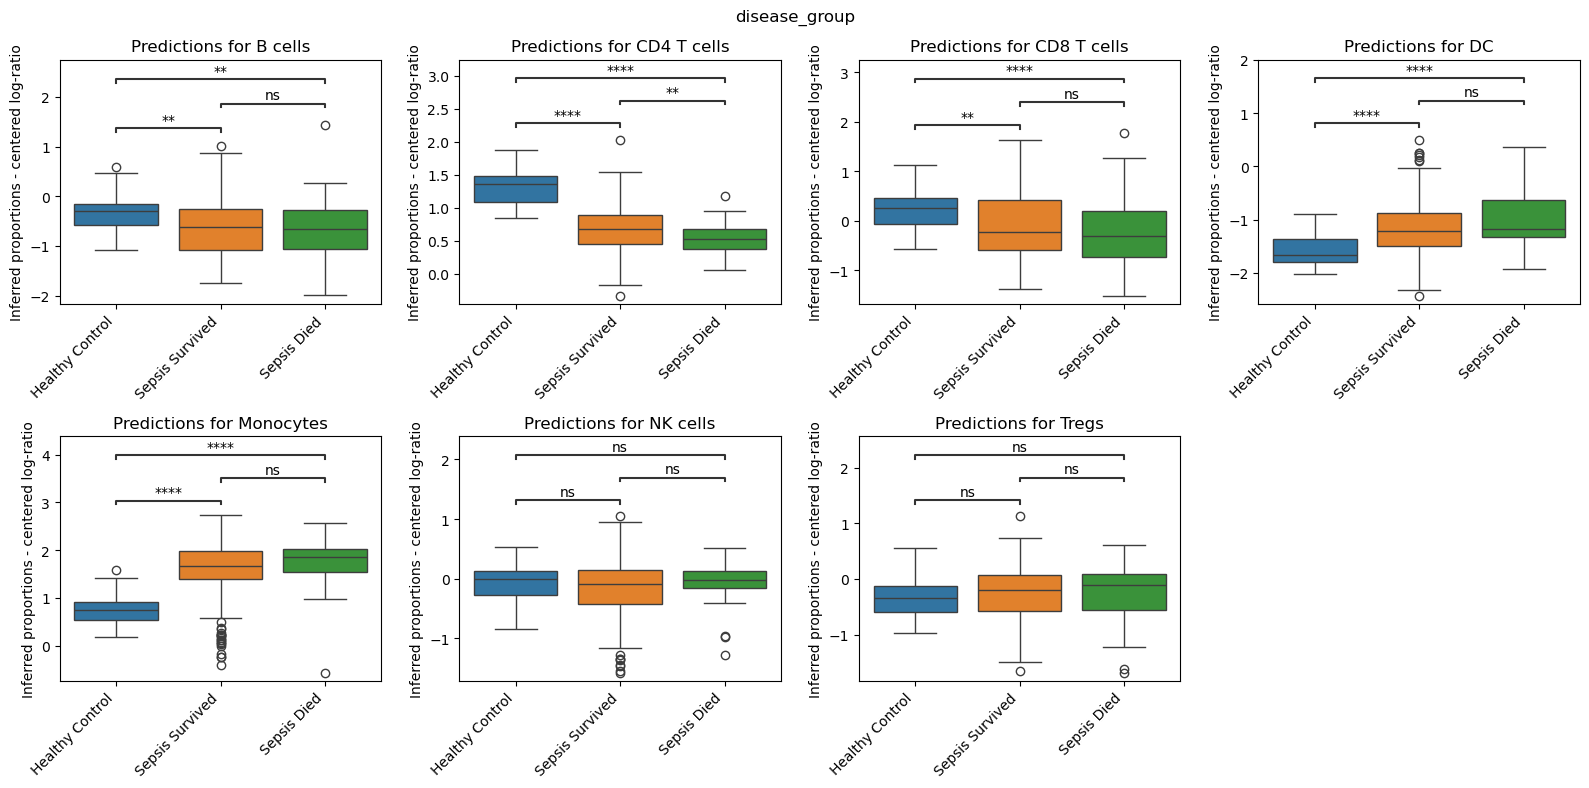

In [6]:
props_with_test(pred, anno, "disease_group", 1e-6)

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Healthy Control vs. Sepsis Survived: t-test independent samples, P_val:1.127e-03 t=3.285e+00
Sepsis Survived vs. Sepsis Died: t-test independent samples, P_val:5.028e-01 t=6.708e-01
Healthy Control vs. Sepsis Died: t-test independent samples, P_val:1.850e-03 t=3.204e+00
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Healthy Control vs. Sepsis Survived: t-test independent samples, P_val:1.851e-28 t=1.217e+01
Sepsis Survived vs. Sepsis Died: t-test independent samples, P_val:4.708e-03 t=2.845e+00
Healthy Control vs. Sepsis Died: t-test independent samples, P_val:8.763e-27 t=1.505e+01
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.

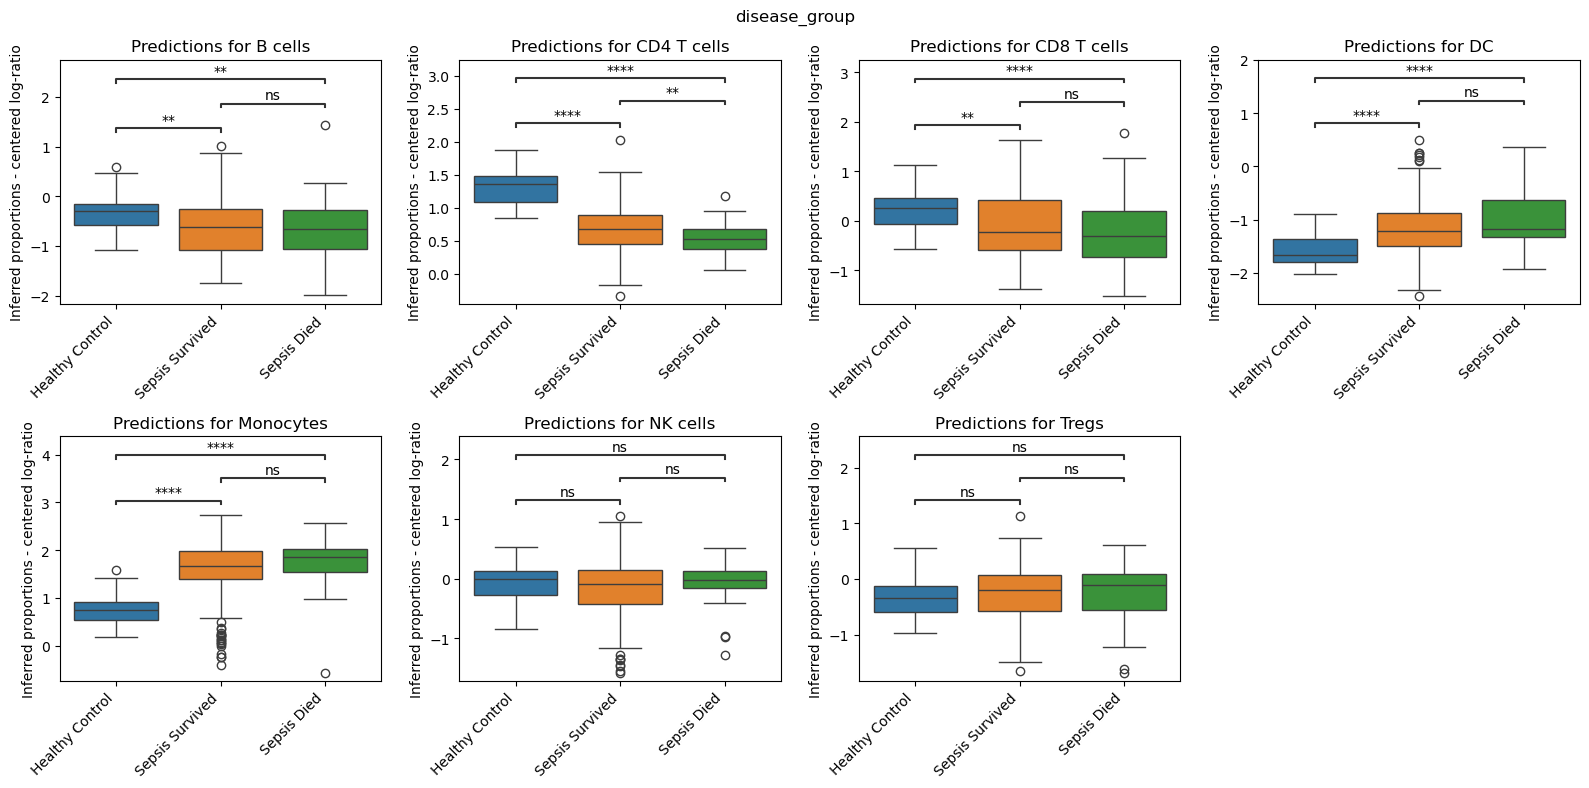

In [7]:
props_with_test(pred, anno, "disease_group", 1e-5)

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Healthy Control vs. Sepsis Survived: t-test independent samples, P_val:1.127e-03 t=3.285e+00
Sepsis Survived vs. Sepsis Died: t-test independent samples, P_val:5.028e-01 t=6.708e-01
Healthy Control vs. Sepsis Died: t-test independent samples, P_val:1.850e-03 t=3.204e+00


p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Healthy Control vs. Sepsis Survived: t-test independent samples, P_val:1.851e-28 t=1.217e+01
Sepsis Survived vs. Sepsis Died: t-test independent samples, P_val:4.708e-03 t=2.845e+00
Healthy Control vs. Sepsis Died: t-test independent samples, P_val:8.763e-27 t=1.505e+01
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Healthy Control vs. Sepsis Survived: t-test independent samples, P_val:7.264e-03 t=2.701e+00
Sepsis Survived vs. Sepsis Died: t-test independent samples, P_val:6.833e-02 t=1.829e+00
Healthy Control vs. Sepsis Died: t-test independent samples, P_val:9.901e-05 t=4.067e+00
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.

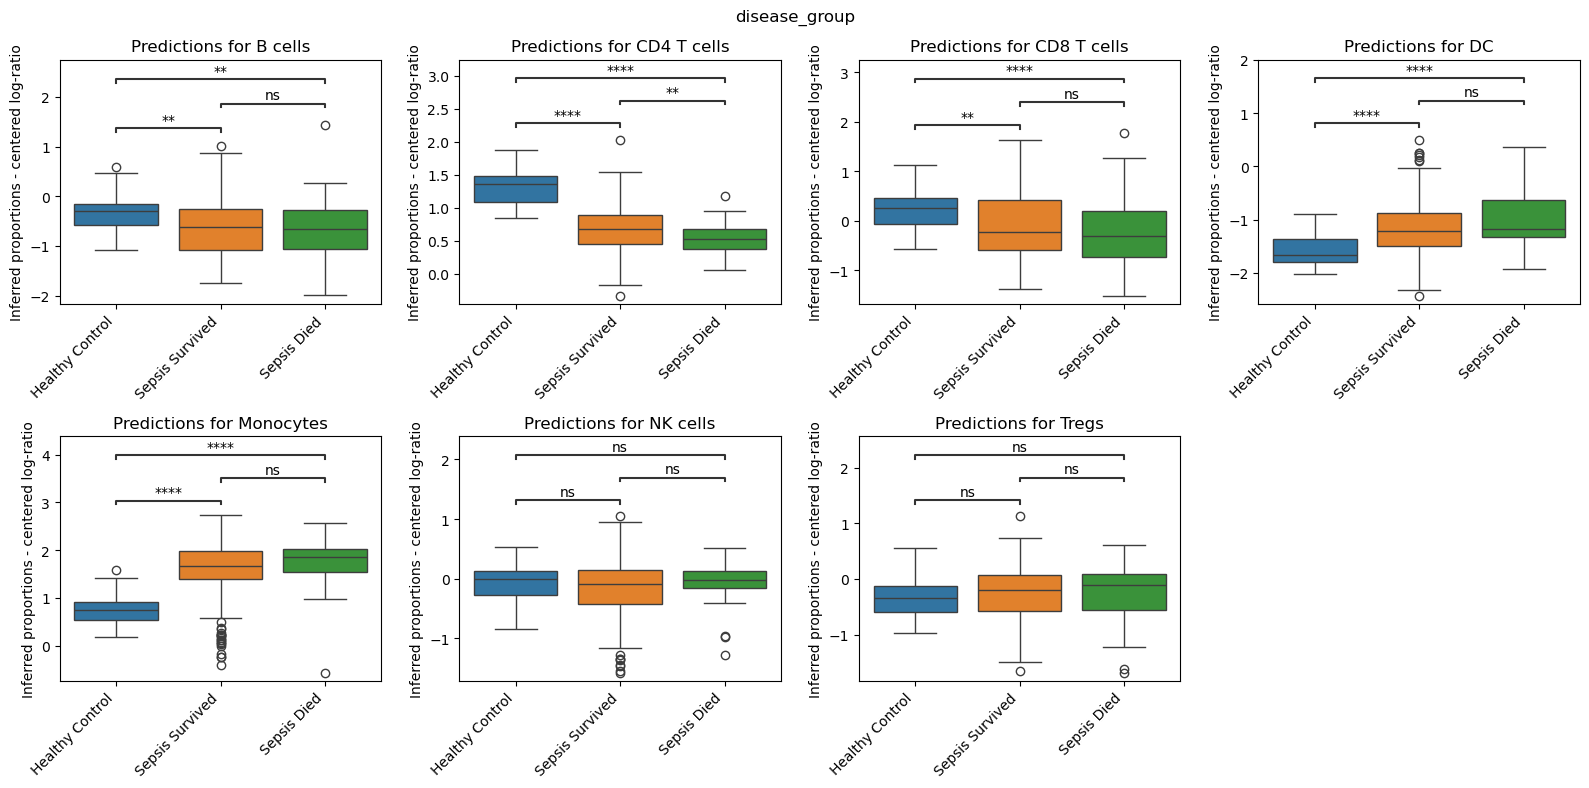

In [8]:
props_with_test(pred, anno, "disease_group", 1e-4)

--> results stable across several pseudocounts

In [9]:
import statsmodels.formula.api as smf

# model = smf.ols("T_cells ~ group + age + sex + batch", data=clr_df).fit()
# print(model.summary())

In [10]:
def props_with_test(df, metadata, condition, pse):
    metadata.index = metadata['geo_accesion']
    celltypes = df.columns.tolist()
    df = df.copy()

    # CLR normalization of the data
    pse = pse
    props_pse = df.replace(0, pse)
    logs = np.log(props_pse)
    clr = logs.sub(logs.mean(axis=1), axis=0)
    clr = pd.DataFrame(clr, columns=celltypes, index=df.index.tolist())

    #return clr

    clr[condition] = metadata.loc[df.index.tolist(), condition]
    df = clr

    n = len(celltypes)
    rows = math.floor(math.sqrt(n))
    cols = math.ceil(n/rows)

    fig, axes = plt.subplots(rows, cols, figsize=(cols * 4, rows * 4))
    axes = np.array(axes) # axes must be an iterable array

    axes = axes.flatten() # flatten in case of multi-dimensionality

    for i, celltype in enumerate(celltypes):
        col_selection = [condition, str(celltype)]
        pred_new = df.copy()
        pred_new = pred_new[col_selection]
        pred_new['SampleID'] = pred_new.index.tolist()
        df_plot = pred_new.melt(id_vars=[condition, 'SampleID'])

        p = sns.boxplot(data=df_plot, x = condition, y = "value", hue = condition, ax=axes[i])
        p.set_xticklabels(p.get_xticklabels(), rotation=45, horizontalalignment='right')

        # define pairs for comparison
        pairs = [("Healthy Control", "Sepsis Survived"), ("Healthy Control", "Sepsis Died"), ("Sepsis Survived", "Sepsis Died")]

        # Add annotations
        annotator = Annotator(p, pairs, data=df_plot, x=condition, y="value")
        annotator.configure(test='t-test_ind', text_format='star', loc='inside')
        annotator.apply_and_annotate()

        axes[i].set_title(f"Predictions for {celltype}")
        axes[i].set_xlabel("")
        axes[i].set_ylabel('Inferred proportions - centered log-ratio')
        #axes[i].set(ylim=(0, 0.55))

    for j in range(n, len(axes)):
        fig.delaxes(axes[j])
    
    fig.suptitle(f"{condition}")

    plt.tight_layout()
    # plt.savefig("Figure_3A.svg", dpi=300)

Analysis without t-test

t-test is not ideal, also since proportions of different cell types are interdependent

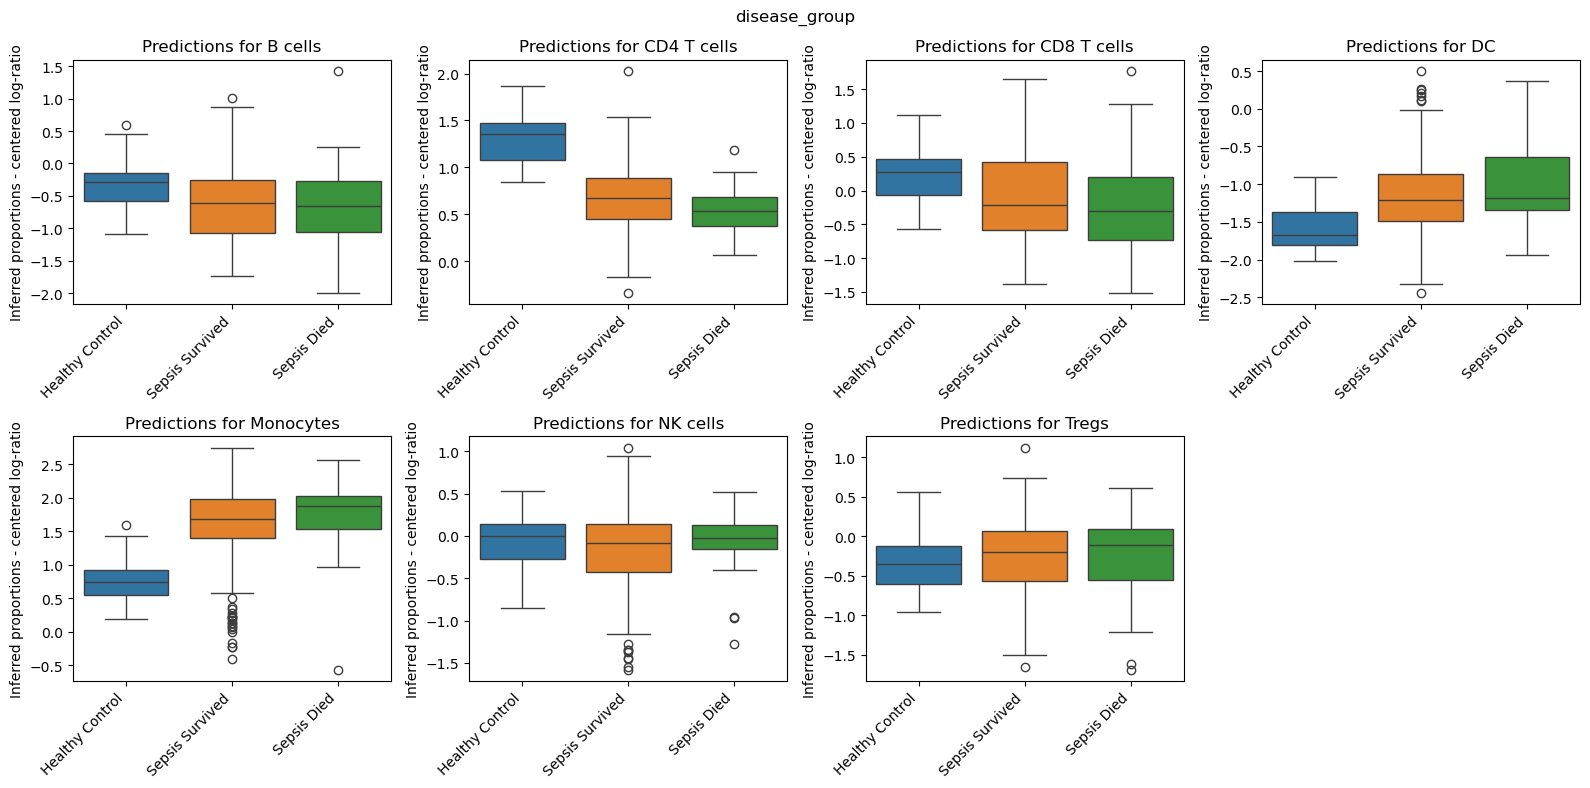

In [11]:
def props_without_test(df, metadata, condition):
    metadata.index = metadata['geo_accesion']
    celltypes = df.columns.tolist()
    df = df.copy()

    # CLR normalization of the data
    pse = 1e-6
    props_pse = df.replace(0, pse)
    logs = np.log(props_pse)
    clr = logs.sub(logs.mean(axis=1), axis=0)
    clr = pd.DataFrame(clr, columns=celltypes, index=df.index.tolist())

    #return clr

    clr[condition] = metadata.loc[df.index.tolist(), condition]
    df = clr

    n = len(celltypes)
    rows = math.floor(math.sqrt(n))
    cols = math.ceil(n/rows)

    fig, axes = plt.subplots(rows, cols, figsize=(cols * 4, rows * 4))
    axes = np.array(axes) # axes must be an iterable array

    axes = axes.flatten() # flatten in case of multi-dimensionality

    for i, celltype in enumerate(celltypes):
        col_selection = [condition, str(celltype)]
        pred_new = df.copy()
        pred_new = pred_new[col_selection]
        pred_new['SampleID'] = pred_new.index.tolist()
        df_plot = pred_new.melt(id_vars=[condition, 'SampleID'])

        p = sns.boxplot(data=df_plot, x = condition, y = "value", hue = condition, ax=axes[i])
        p.set_xticklabels(p.get_xticklabels(), rotation=45, horizontalalignment='right')

        axes[i].set_title(f"Predictions for {celltype}")
        axes[i].set_xlabel("")
        axes[i].set_ylabel('Inferred proportions - centered log-ratio')
        #axes[i].set(ylim=(0, 0.55))

    for j in range(n, len(axes)):
        fig.delaxes(axes[j])
    
    fig.suptitle(f"{condition}")

    plt.tight_layout()

props_without_test(pred, anno, "disease_group")

In [12]:
a = anno[anno['disease_group']=='Healthy Control'].index.tolist()
b = list(np.random.choice(anno[anno['disease_group']=='Sepsis Survived'].index.tolist(), 50, replace=False))
c = anno[anno['disease_group']=='Sepsis Died'].index.tolist()
indices = a+b+c

In [13]:
model = joblib.load('../../grood_runs/GrooD_Hao_Baghela/intersect_mRNA/train/model/Model.pkl')
model_file = model['model']
estimators = model['metadata']['estimators']

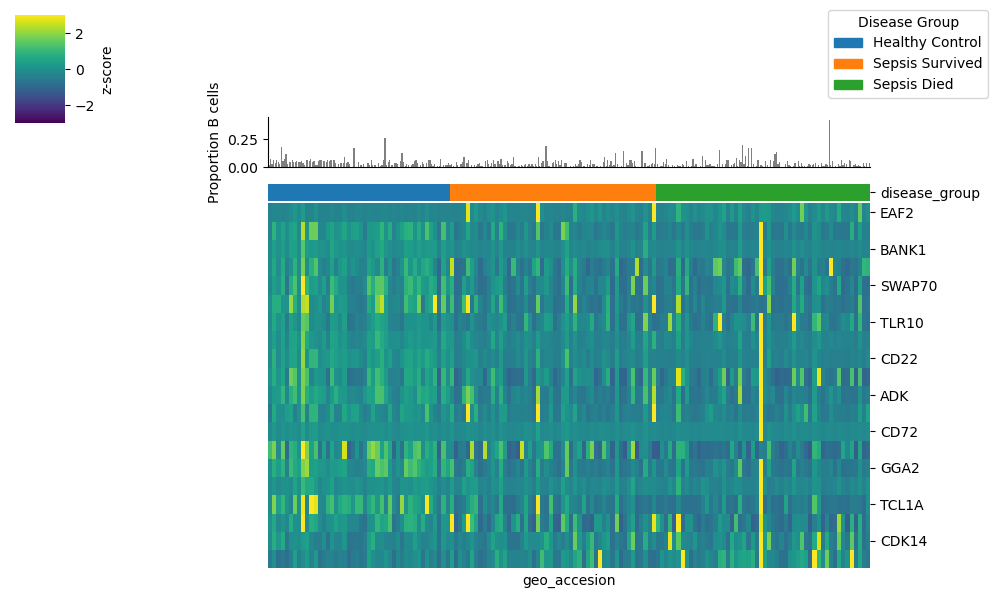

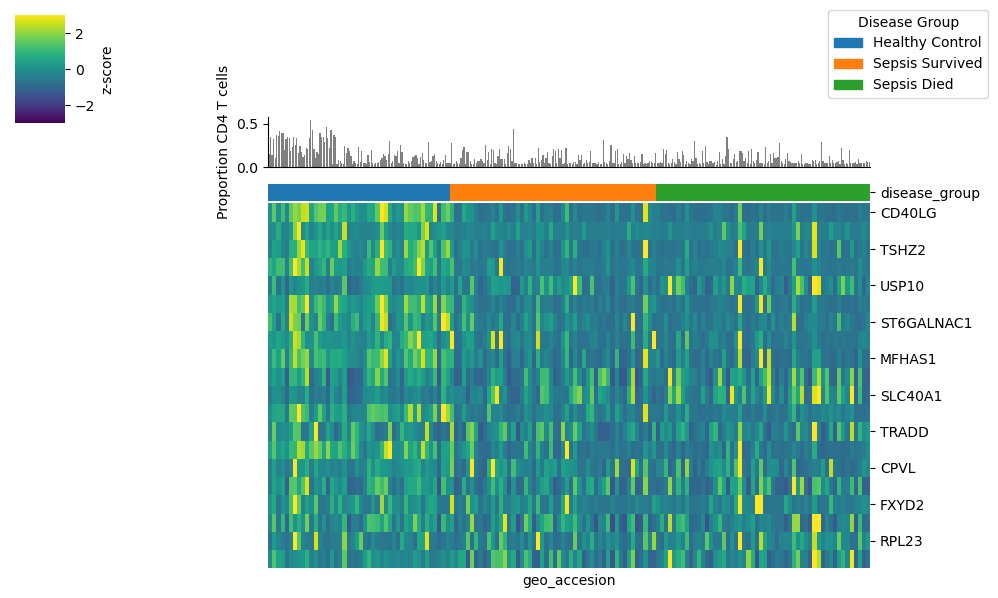

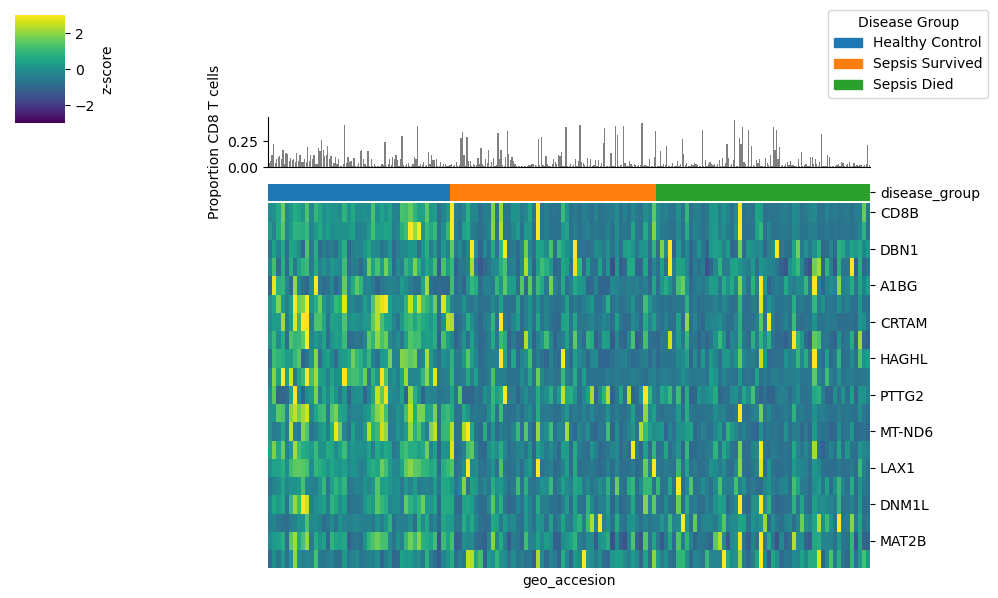

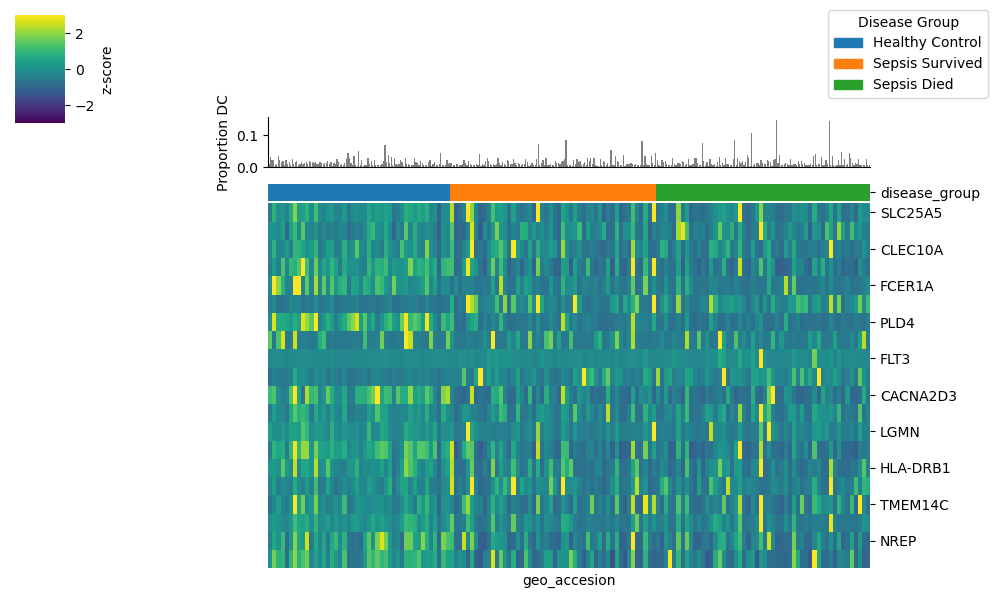

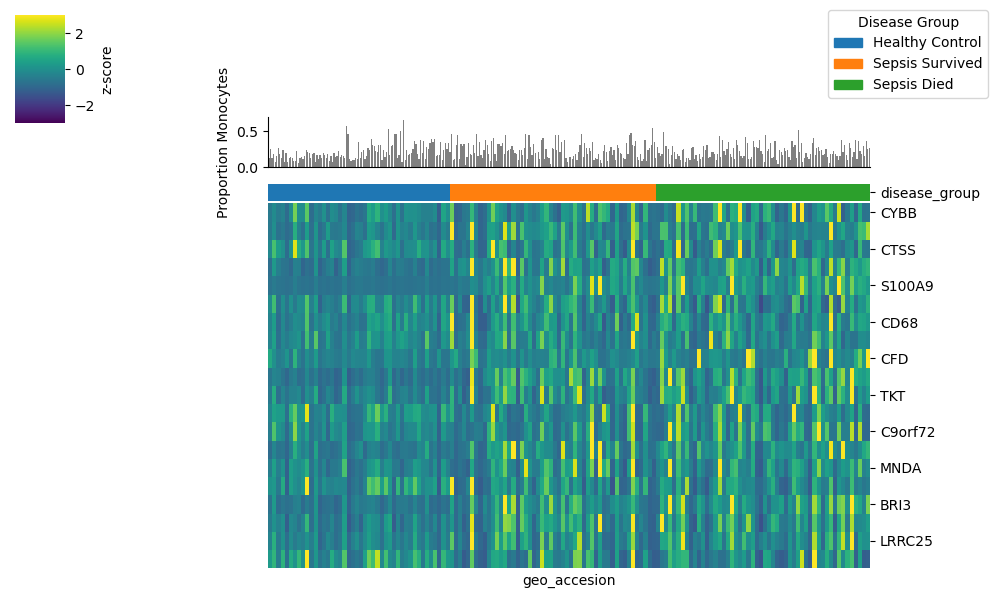

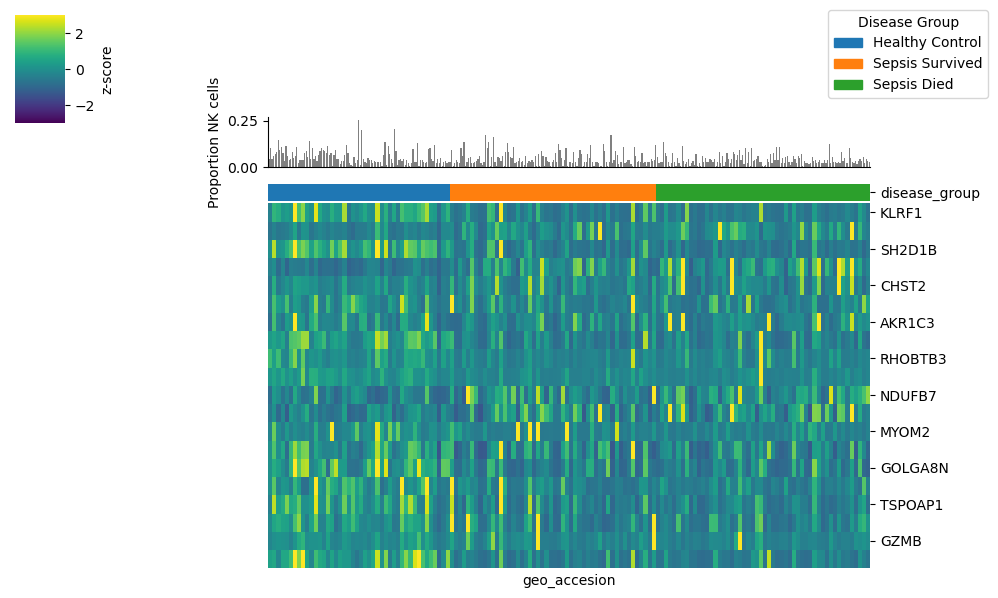

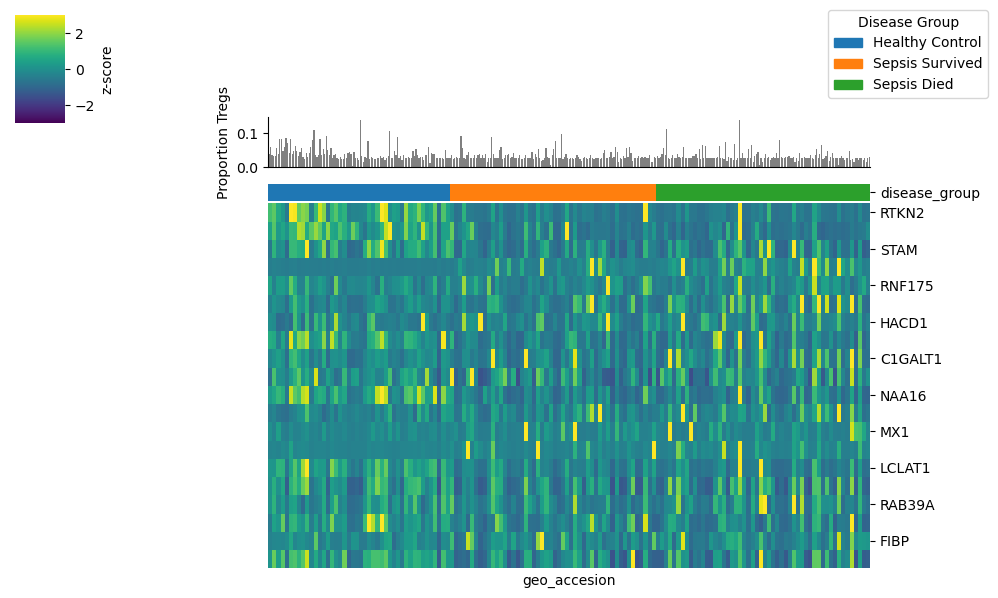

In [14]:
# Function for heatmap
import matplotlib.patches as mpatches

def explain_heatmap_features(model, estimators, data, prop, cell_type, anno, samples):

    # Get most important features
    index = estimators.index(cell_type)
    feature_importance = model.estimators_[index].feature_importances_
    sorted_idx = np.argsort(feature_importance) # sort highest to lowest importance and get the feature indices
    most_important_features = sorted_idx[-20:] # get 20 most important features
    genes = np.flip(np.array(model.estimators_[index].feature_names_in_.tolist())[most_important_features])

    # Format data
    data_selected = data[genes].transpose() # subset bulk data

    #data_selected = np.log1p(data_selected)
    #data_selected = pd.DataFrame(index=data_selected.index.tolist(), columns=data_selected.columns.tolist(), data=stats.zscore(np.array(data_selected), axis = 1))
    prop_series = pd.Series(prop[cell_type]) # series for proportion for cell type investigated here

    # Remove genes with all-zero expression across samples
    df_filtered = data_selected
    non_zero_genes = (df_filtered.sum(axis=1) != 0)
    df_filtered = df_filtered.loc[non_zero_genes]
    df_filtered = df_filtered[samples]

    anno = anno.loc[df_filtered.columns.tolist(),]

    # Make a color palette for the unique disease groups
    palette = dict(zip(['Healthy Control', 'Sepsis Survived', 'Sepsis Died'], sns.color_palette("tab10", anno["disease_group"].nunique())))

    # Map disease groups to colors
    row_colrs = anno["disease_group"].map(palette)

    # Create clustermap
    g = sns.clustermap(
        df_filtered,
        col_cluster=False,
        row_cluster=False,
        col_colors=row_colrs,
        cmap="viridis",
        vmin=-3, vmax=3, 
        cbar_kws={"label": "z-score"}, 
        figsize=(10, 6),
        dendrogram_ratio=0.3,
        z_score=0,
        xticklabels=False
    )

    # Build legend patches from the palette
    handles = [mpatches.Patch(color=color, label=group)
            for group, color in palette.items()]

    # Add the legend to the heatmap
    plt.legend(handles=handles,
            title="Disease Group",
            bbox_to_anchor=(1, 1),   # position: top-right outside
            bbox_transform=plt.gcf().transFigure,
            loc='upper right')


    # Reorder the sample values to match clustered column order
    #col_order = [data_selected.columns[i] for i in g.dendrogram_col.reordered_ind]
    #prop_series_reordered = prop_series[col_order]

    # Add a new axis on top for the bar plot
    # Position: [left, bottom, width, height] in figure coordinates
    bar_height = 0.5  # relative height of bar plot
    heatmap_pos = g.ax_heatmap.get_position()

    bar_ax = g.fig.add_axes([
        heatmap_pos.x0,                      # left
        heatmap_pos.y1 + 0.06,               # bottom just above heatmap
        heatmap_pos.width,                   # same width as heatmap
        bar_height / g.fig.get_size_inches()[1]  # normalized height
    ])

    # ---- 5. Plot bars ----
    bar_ax.bar(
        x=np.arange(len(prop_series)),
        #height=prop_series_reordered,
        height=prop_series,
        color="gray"
    )

    # Remove x ticks
    bar_ax.set_xticks([])
    #bar_ax.set_xlim(-0.5, len(prop_series_reordered) - 0.5)
    bar_ax.set_xlim(-0.5, len(prop_series) - 0.5)
    bar_ax.set_ylabel(f"Proportion {cell_type}")

    # Optional: make y-axis more compact
    bar_ax.spines["top"].set_visible(False)
    bar_ax.spines["right"].set_visible(False)

    #plt.title(f"Prediction and Expression of most important features for {cell_type}", )
    plt.savefig(f"Figure_3B_{cell_type}.svg", dpi=300)

    return g

bulk_sorted = bulks.loc[anno.index.tolist(),]

for cell_type in estimators:
    explain_heatmap_features(model_file, estimators, bulk_sorted, pred, cell_type, anno, indices)

Reanalyse by summarizing disease groups, test different summary and normalization approaches.

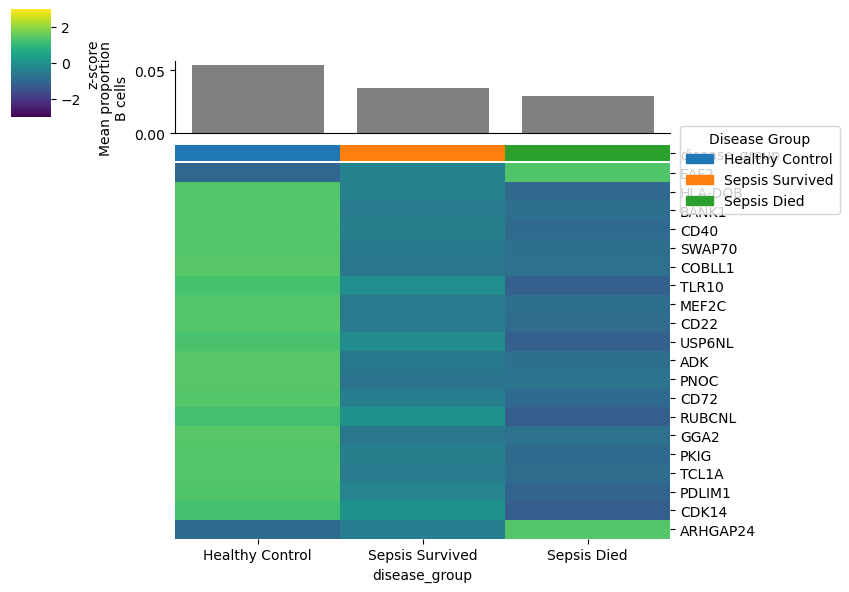

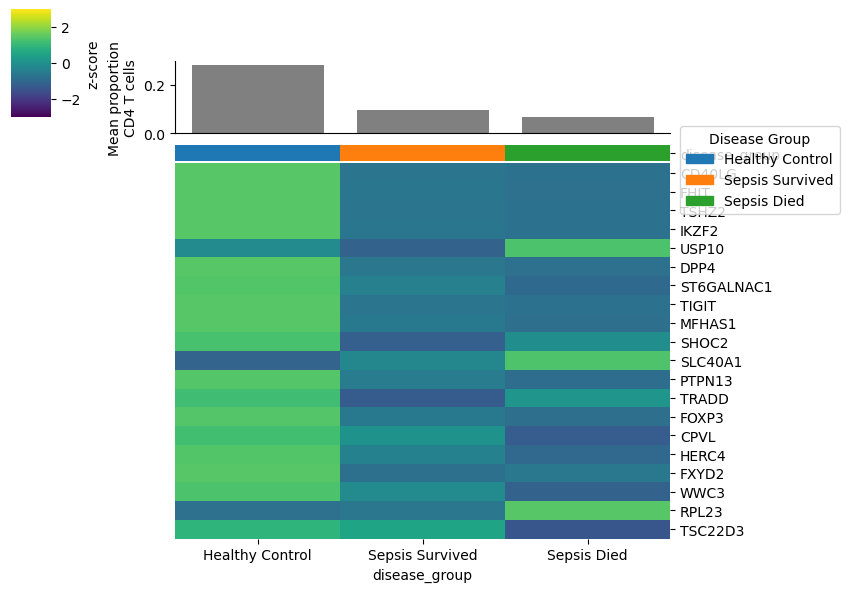

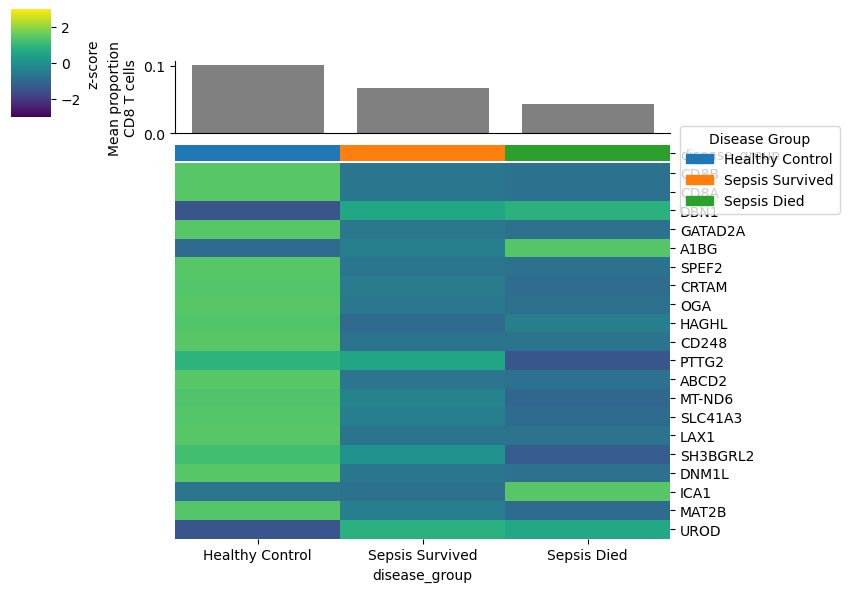

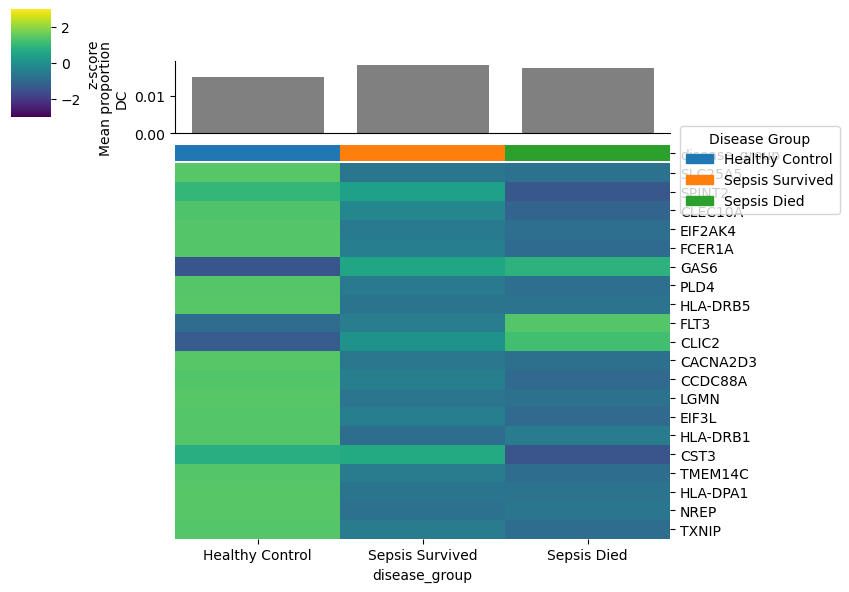

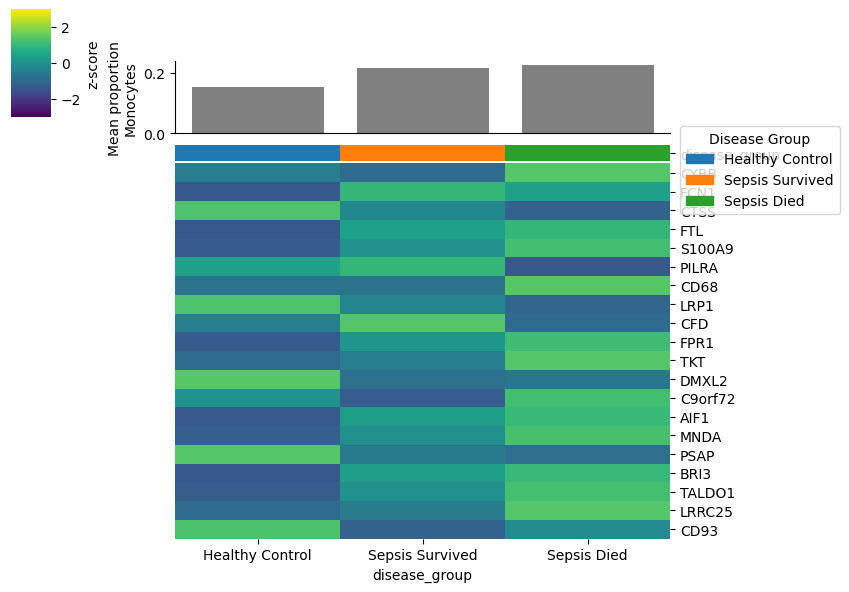

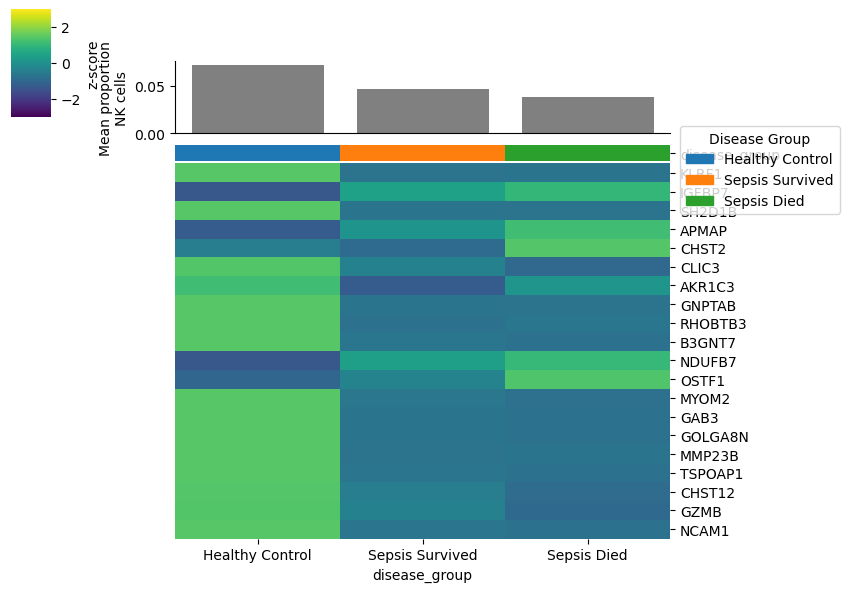

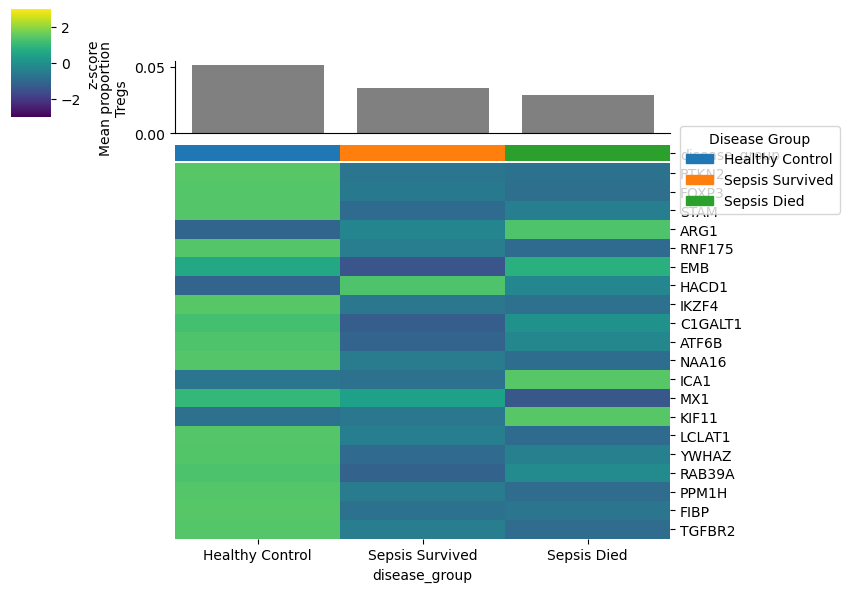

In [15]:
# Function for heatmap (group-summary per gene per disease group)
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy import stats

def explain_heatmap_features(
    model,
    estimators,
    data,
    prop,
    cell_type,
    anno,
    samples,
    agg="mean",                 # "mean" | "median" | "gmean"
    normalize=None,             # None | "zscore" | "log1p" | "log1p_zscore"
    plot_heatmap=True,          # if False: just return the summarized matrix
    n_genes=20,
    figsize=(8, 6),
    cmap="viridis"
):

    # 1) Most important features (genes) for this cell type
    index = estimators.index(cell_type)
    feature_importance = model.estimators_[index].feature_importances_
    sorted_idx = np.argsort(feature_importance)
    most_important_features = sorted_idx[-n_genes:]
    genes = np.flip(np.array(model.estimators_[index].feature_names_in_.tolist())[most_important_features])

    # 2) Subset and align data/anno to samples
    data_selected = data.loc[samples, genes].copy()  # rows=samples, cols=genes
    anno_sub = anno.loc[samples].copy()

    # Remove genes with all-zero expression across the selected samples
    non_zero_genes = (data_selected.sum(axis=0) != 0)
    data_selected = data_selected.loc[:, non_zero_genes]

    # 3) Aggregate expression per gene per disease group
    groups = anno_sub["disease_group"].astype(str)

    if agg not in {"mean", "median", "gmean"}:
        raise ValueError("agg must be one of: 'mean', 'median', 'gmean'.")

    if agg == "mean":
        expr_group = data_selected.groupby(groups).mean()
    elif agg == "median":
        expr_group = data_selected.groupby(groups).median()
    else:
        def _gmean_df(df):
            eps=1e-9
            return np.exp(np.log(df + eps).mean(axis=0)) - eps

        expr_group = data_selected.groupby(groups).apply(_gmean_df)

    # expr_group is disease_group x genes
    mat = expr_group.T

    # 4) Optional normalization
    label = "expression"
    if normalize is None:
        pass
    elif normalize == "log1p":
        mat = np.log1p(mat)
        label = "log1p(expression)"
    elif normalize == "zscore":
        mat = pd.DataFrame(
            data=stats.zscore(mat.values, axis=1, nan_policy="omit"),
            index=mat.index,
            columns=mat.columns
        )
        label = "z-score"
    elif normalize == "log1p_zscore":
        mat = np.log1p(mat)
        mat = pd.DataFrame(
            data=stats.zscore(mat.values, axis=1, nan_policy="omit"),
            index=mat.index,
            columns=mat.columns
        )
        label = "log1p(expression) z-score"
    else:
        raise ValueError("normalize must be one of: None, 'zscore', 'log1p', 'log1p_zscore'.")

    if not plot_heatmap:
        return mat

    # 5) Heatmap (genes x disease groups)
    desired_order = ["Healthy Control", "Sepsis Survived", "Sepsis Died"]
    col_order = [c for c in desired_order if c in mat.columns] + [c for c in mat.columns if c not in desired_order]
    mat = mat[col_order]

    # color strip for disease groups (columns)
    palette = dict(zip(col_order, sns.color_palette("tab10", len(col_order))))
    col_colors = pd.Series(mat.columns, index=mat.columns).map(palette)

    # If z-scored, symmetric limits look best; otherwise let it autoscale.
    vmin = vmax = None
    if normalize in {"zscore", "log1p_zscore"}:
        vmin, vmax = -3, 3

    g = sns.clustermap(
        mat,
        col_cluster=False,
        row_cluster=False,
        col_colors=col_colors,
        cmap=cmap,
        vmin=vmin, vmax=vmax,
        cbar_kws={"label": label},
        figsize=figsize,
        dendrogram_ratio=0.25,
        xticklabels=True,
        yticklabels=True
    )

    # Legend for disease group colors
    handles = [mpatches.Patch(color=palette[group], label=group) for group in col_order]
    g.ax_heatmap.legend(
        handles=handles,
        title="Disease Group",
        bbox_to_anchor=(1.02, 1.1),
        loc="upper left",
        borderaxespad=0
    )

    # --- 6) Bar plot of predicted proportions above the heatmap (summarized per group) ---
    # Summarize proportion per disease group to match the grouped heatmap
    prop_series = pd.Series(prop[cell_type], index=samples)
    prop_group = prop_series.groupby(groups).mean().reindex(col_order)

    heatmap_pos = g.ax_heatmap.get_position()
    bar_ax = g.fig.add_axes([
        heatmap_pos.x0,
        heatmap_pos.y1 + 0.05,
        heatmap_pos.width,
        0.12
    ])

    bar_ax.bar(np.arange(len(prop_group)), prop_group.values, color="gray")
    bar_ax.set_xticks([])
    bar_ax.set_xlim(-0.5, len(prop_group) - 0.5)
    bar_ax.set_ylabel(f"Mean proportion\n{cell_type}")

    bar_ax.spines["top"].set_visible(False)
    bar_ax.spines["right"].set_visible(False)

    # Save
    # g.fig.savefig(f"Figure_3B_{cell_type}_{agg}_{normalize or 'raw'}.svg", dpi=300, bbox_inches="tight")

    return g


bulk_sorted = bulks.loc[anno.index.tolist(),]

for cell_type in estimators:
    explain_heatmap_features(
        model_file, estimators, bulk_sorted, pred, cell_type, anno, indices,
        agg="median",            # "mean" | "median" | "gmean"
        normalize="zscore",      # None | "log1p" | "zscore" | "log1p_zscore"
        plot_heatmap=True
    )


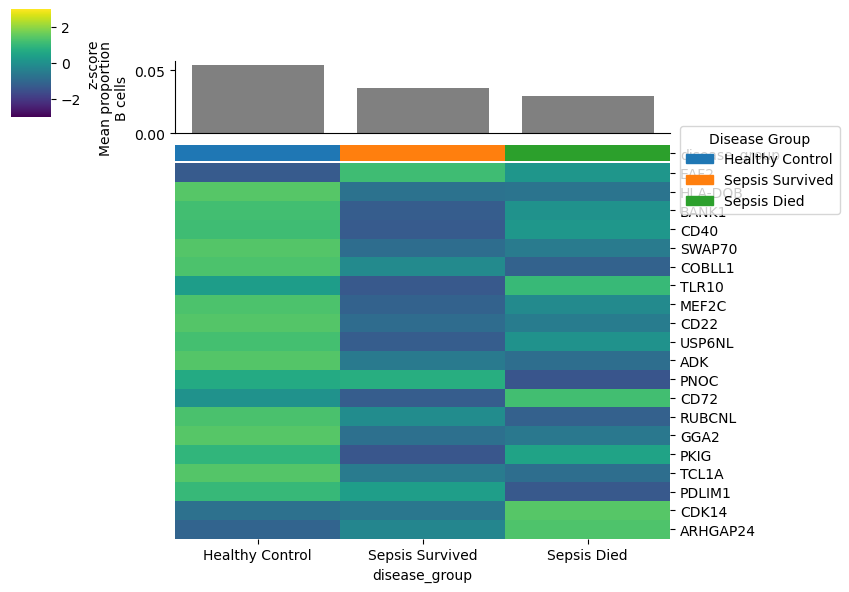

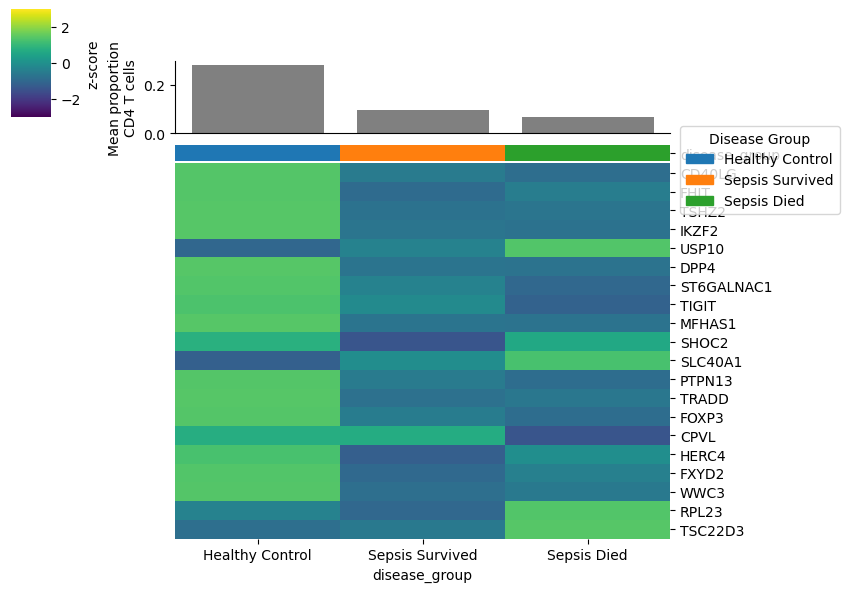

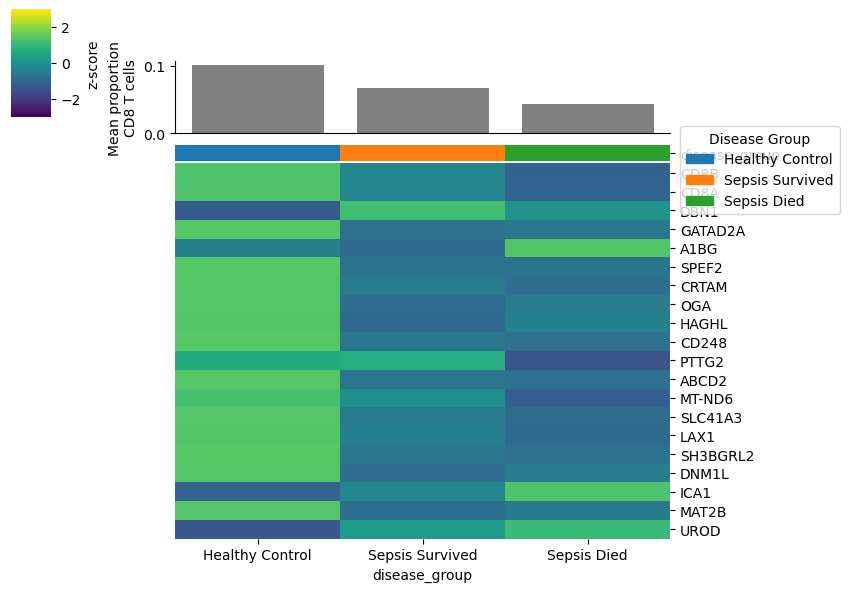

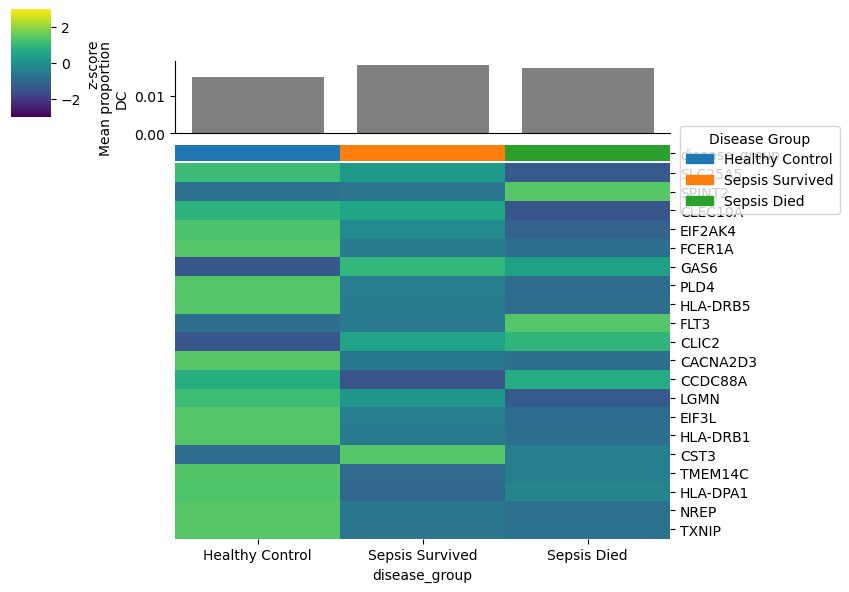

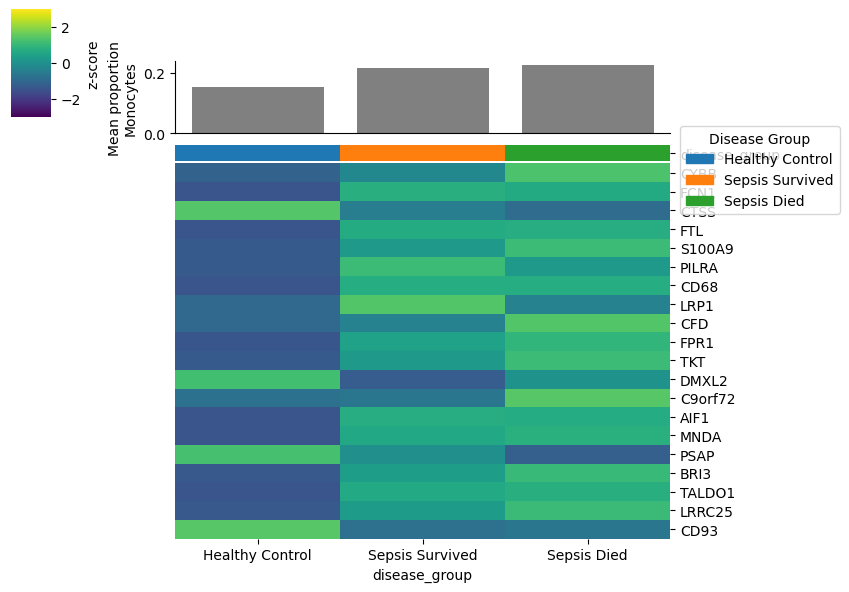

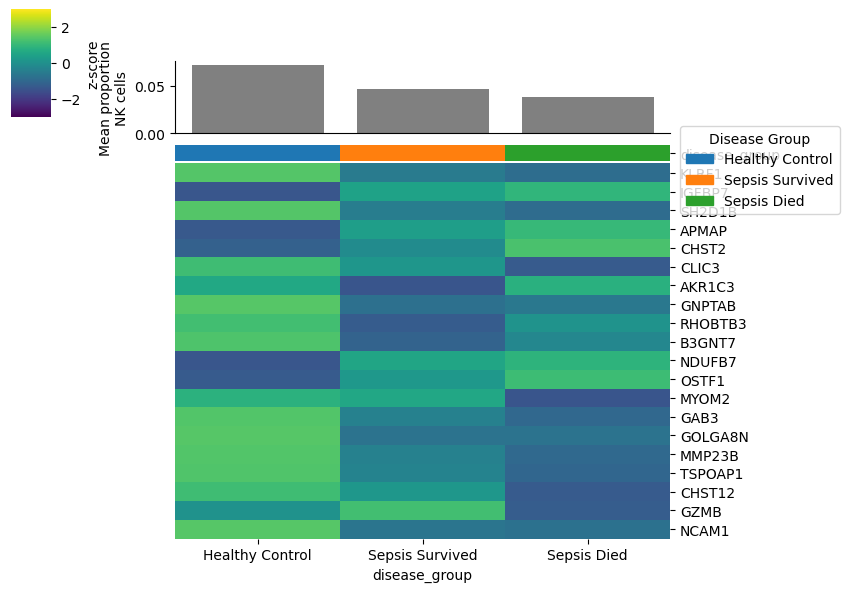

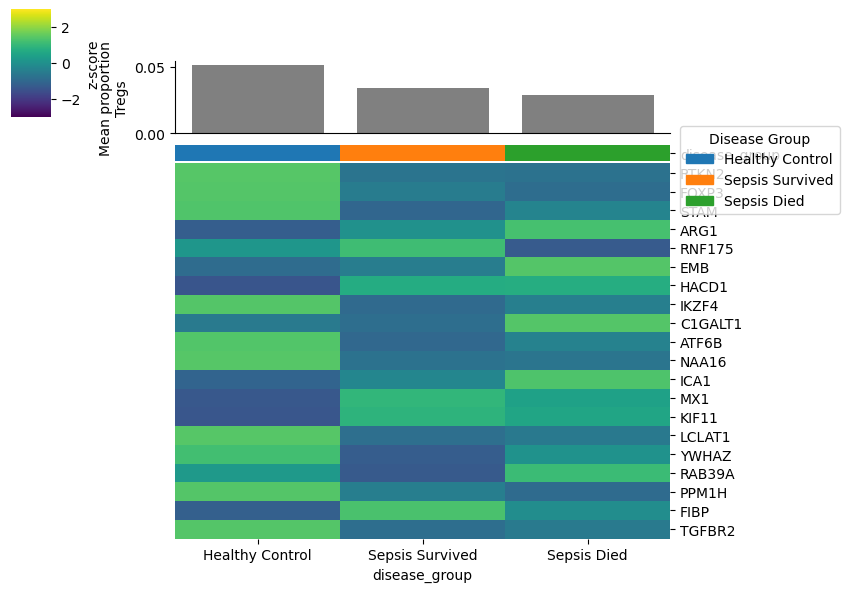

In [16]:
for cell_type in estimators:
    explain_heatmap_features(
        model_file, estimators, bulk_sorted, pred, cell_type, anno, indices,
        agg="mean",            # "mean" | "median" | "gmean"
        normalize="zscore",      # None | "log1p" | "zscore" | "log1p_zscore"
        plot_heatmap=True
    )

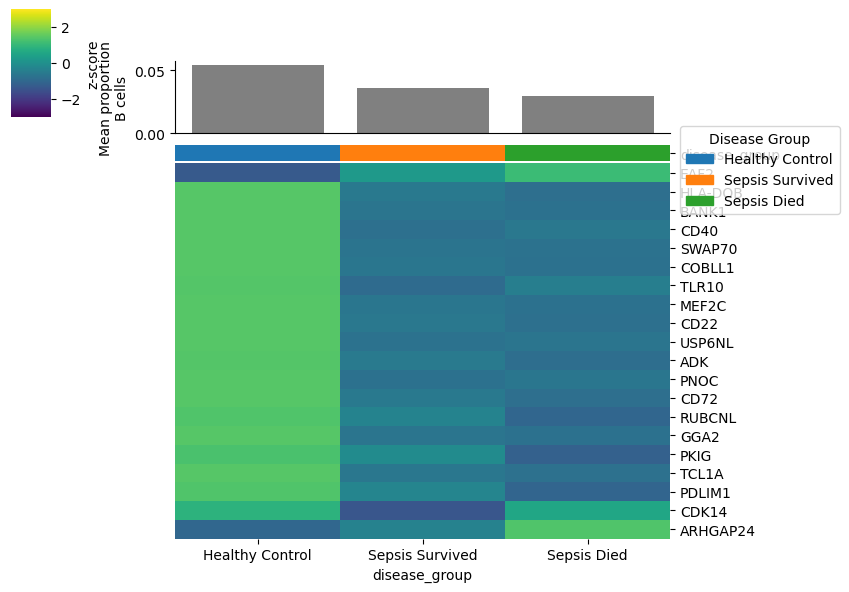

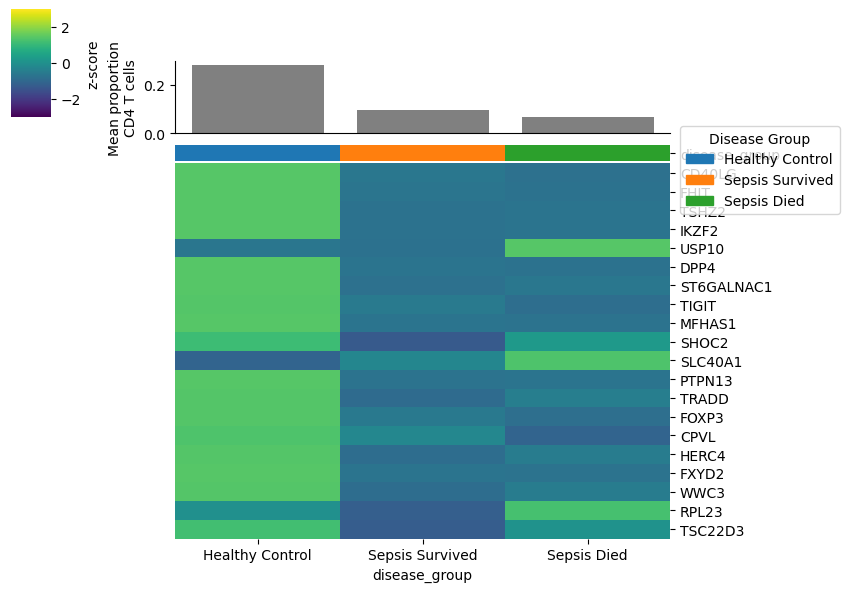

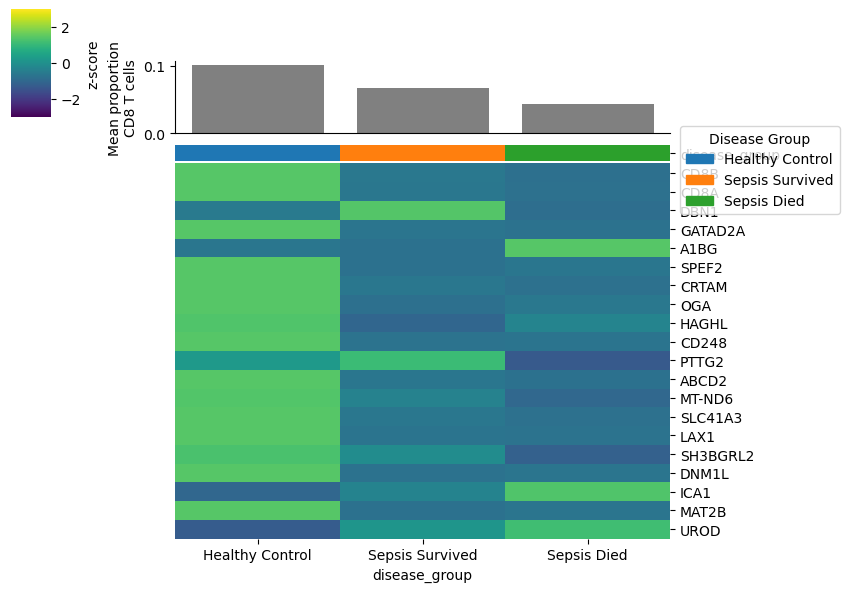

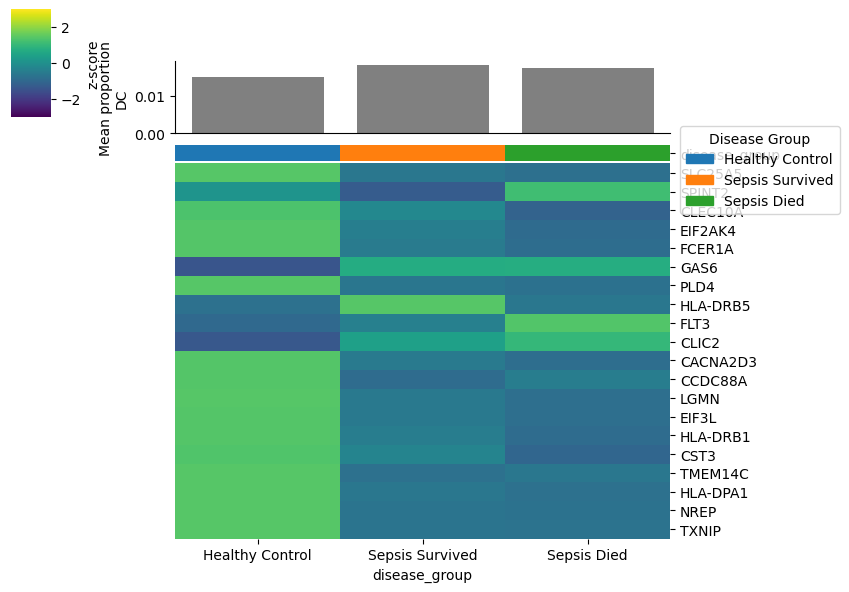

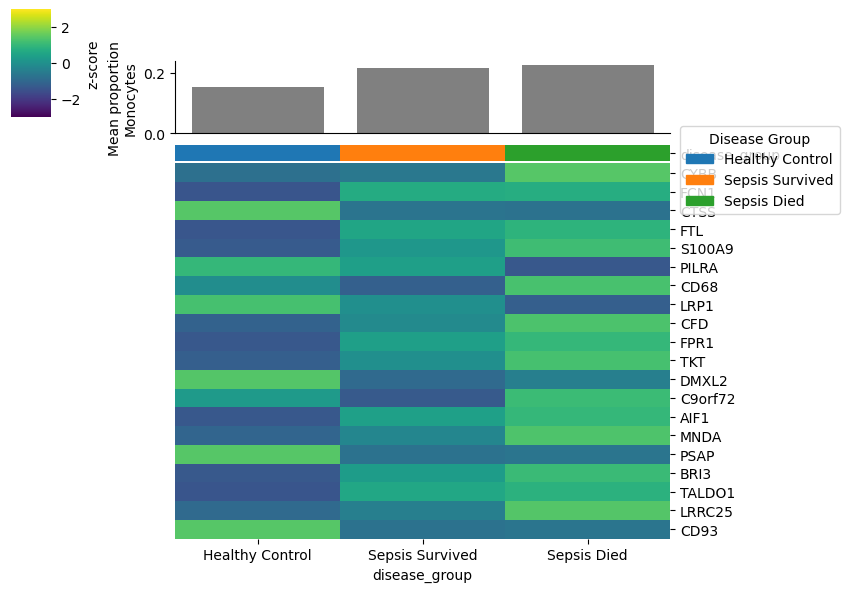

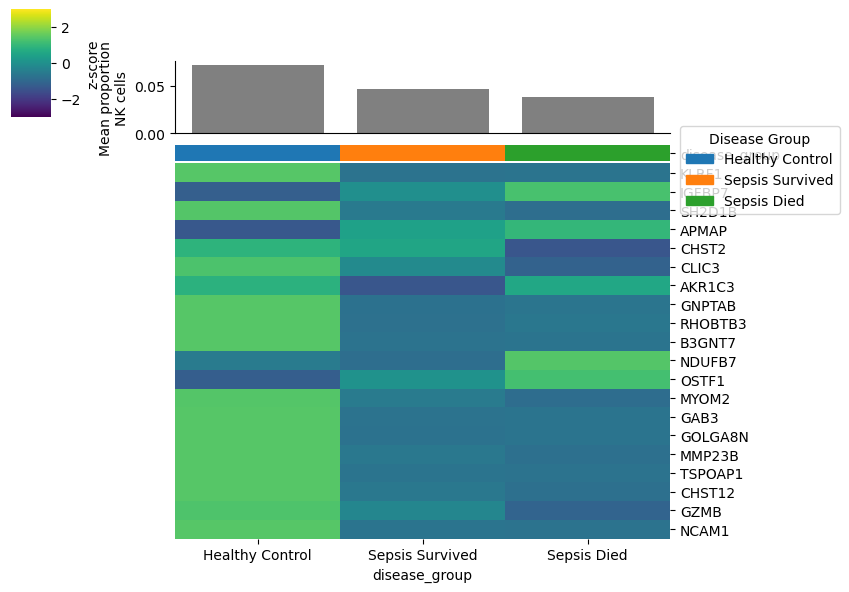

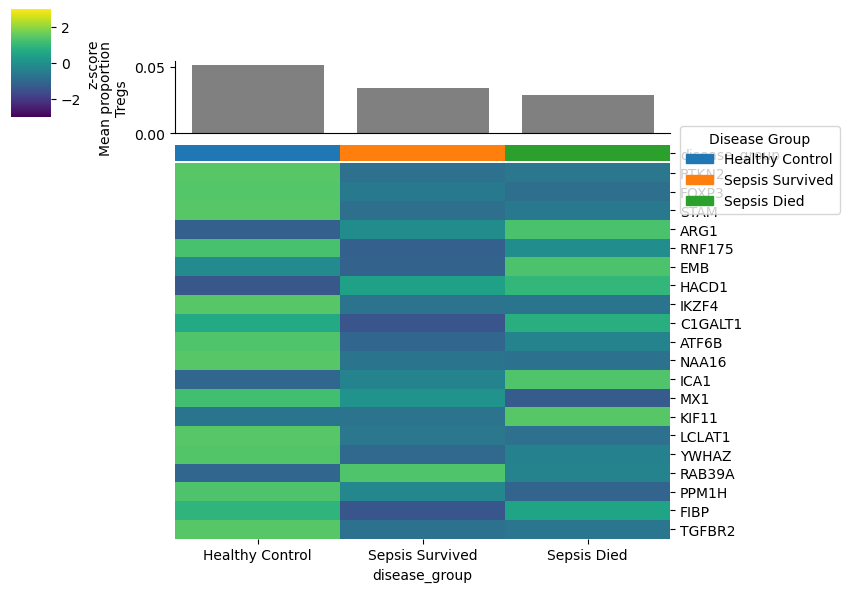

In [17]:
for cell_type in estimators:
    explain_heatmap_features(
        model_file, estimators, bulk_sorted, pred, cell_type, anno, indices,
        agg="gmean",            # "mean" | "median" | "gmean"
        normalize="zscore",      # None | "log1p" | "zscore" | "log1p_zscore"
        plot_heatmap=True
    )

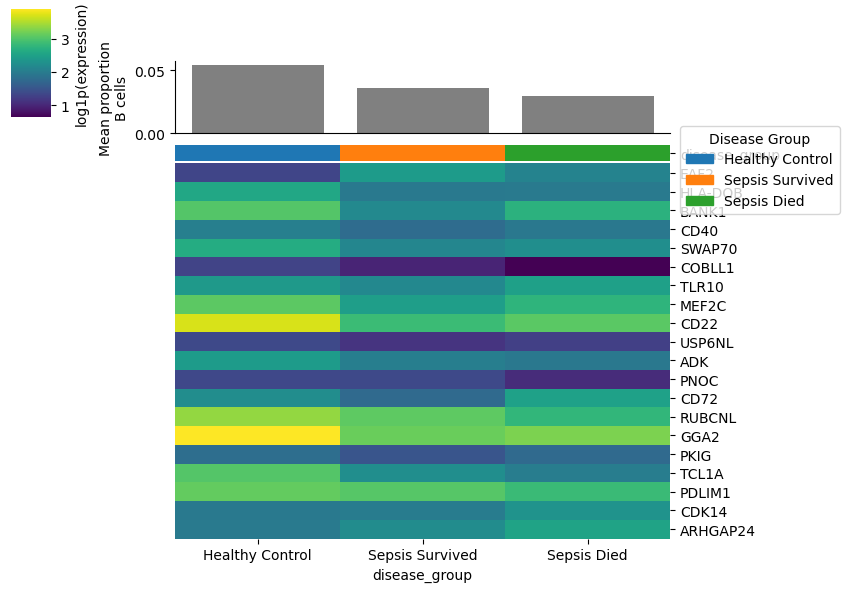

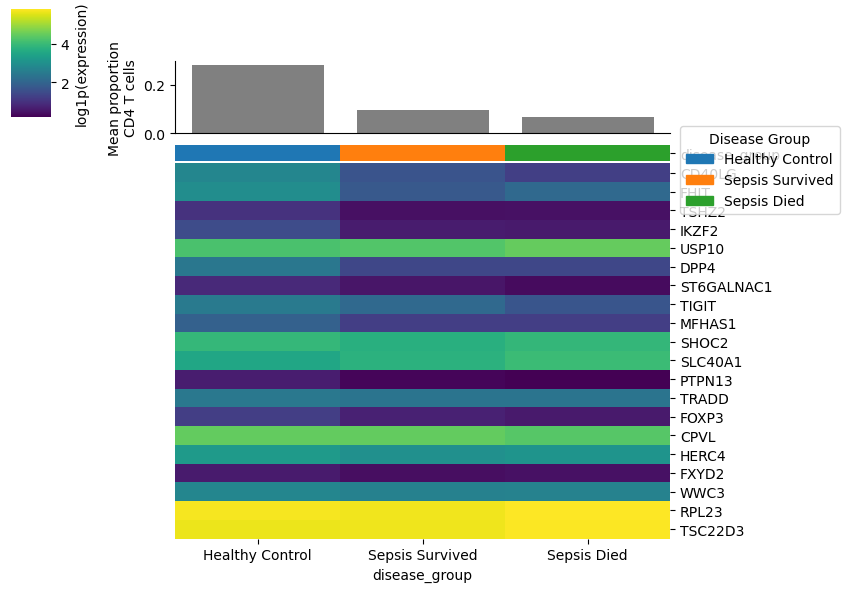

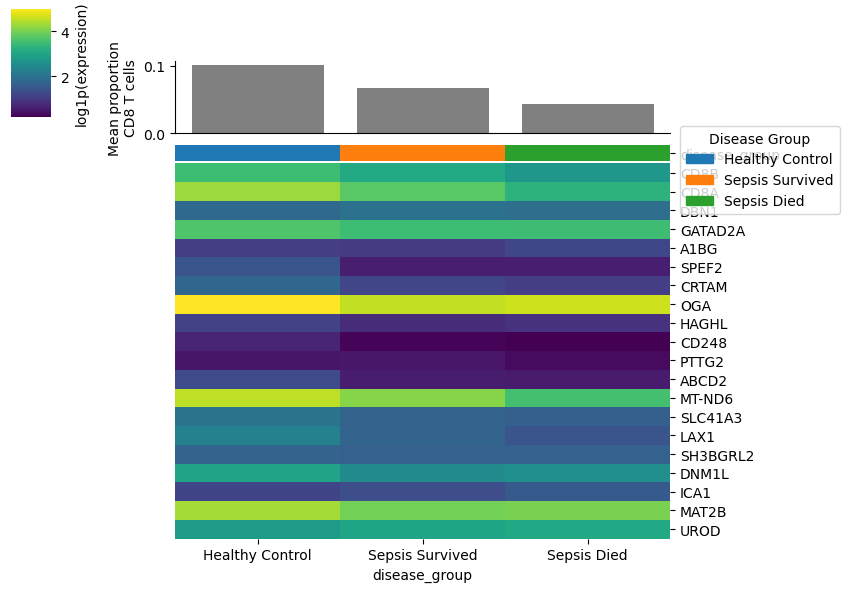

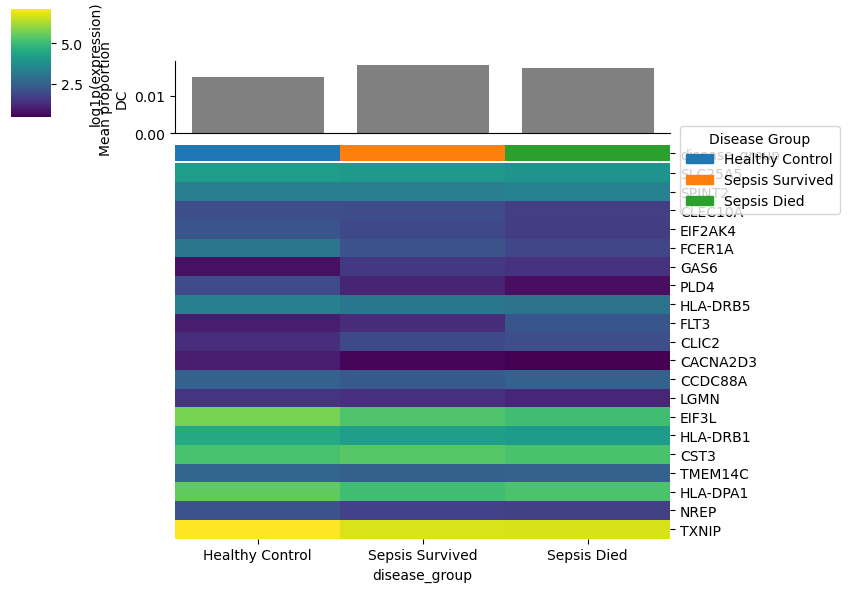

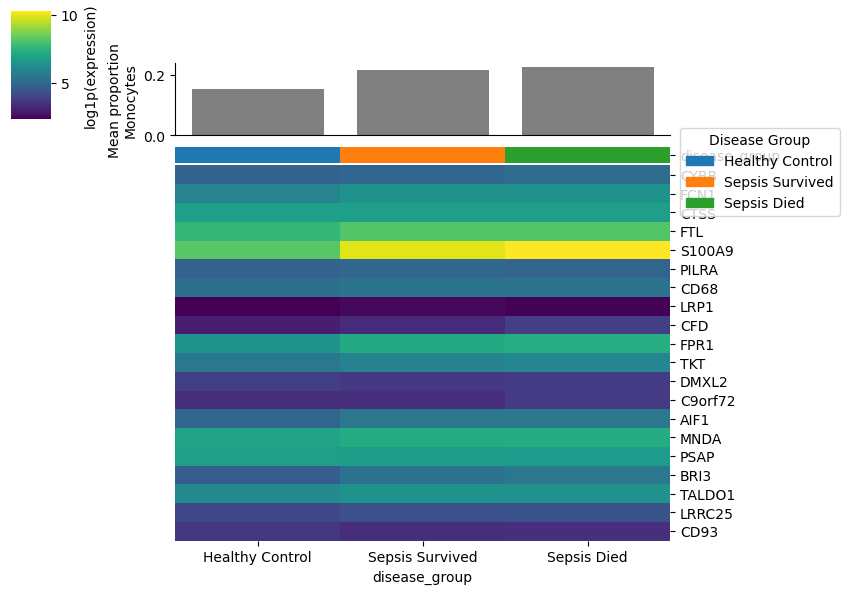

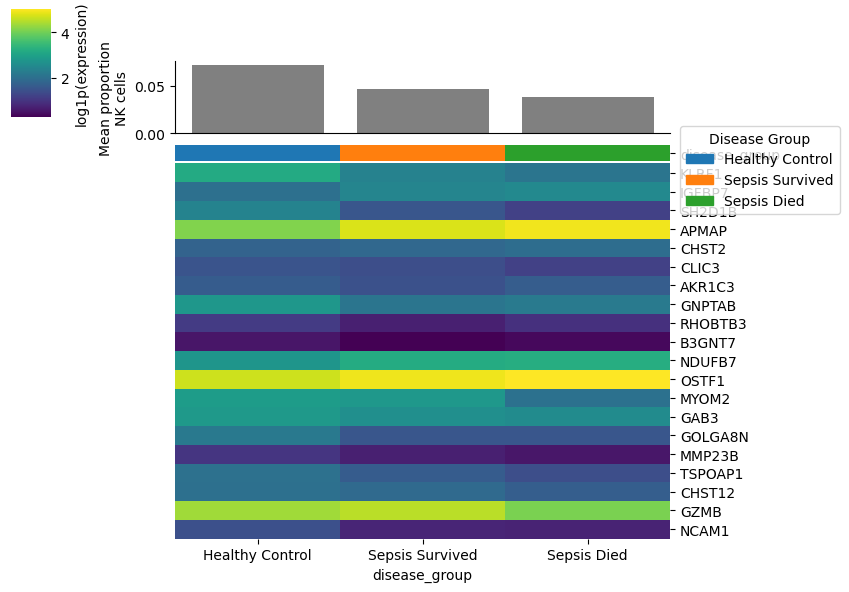

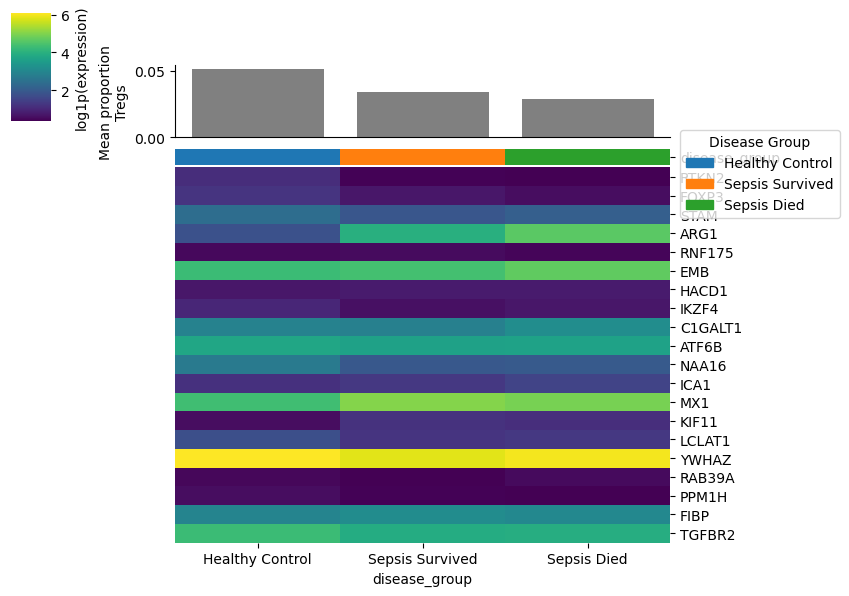

In [18]:
for cell_type in estimators:
    explain_heatmap_features(
        model_file, estimators, bulk_sorted, pred, cell_type, anno, indices,
        agg="mean",            # "mean" | "median" | "gmean"
        normalize="log1p",      # None | "log1p" | "zscore" | "log1p_zscore"
        plot_heatmap=True
    )

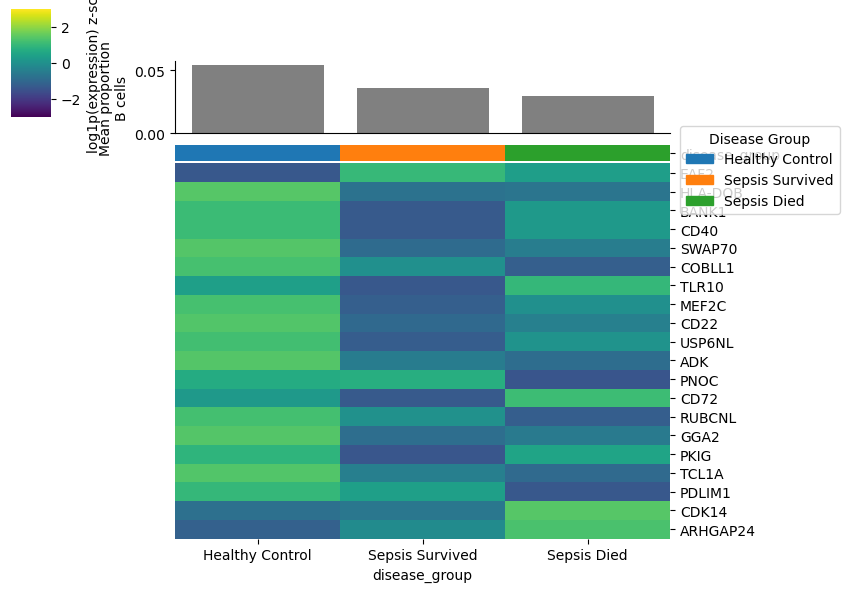

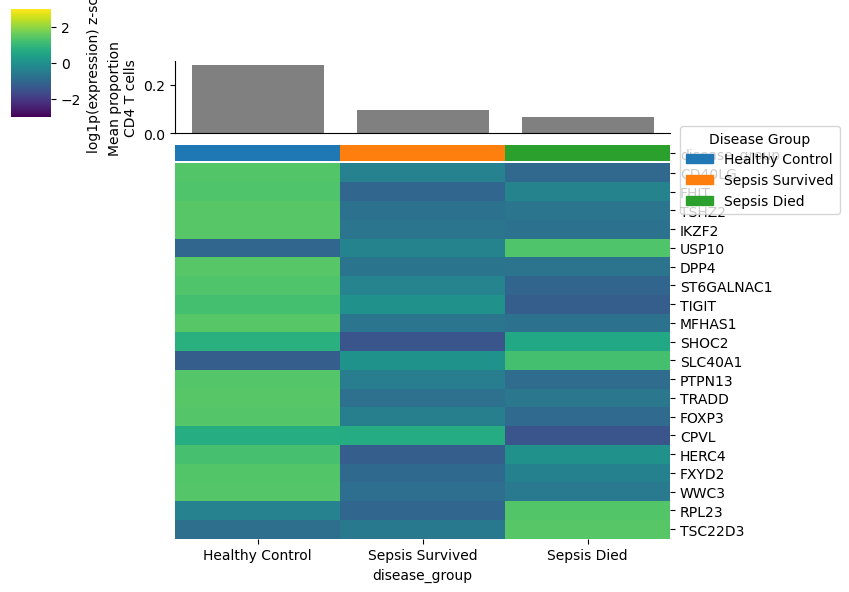

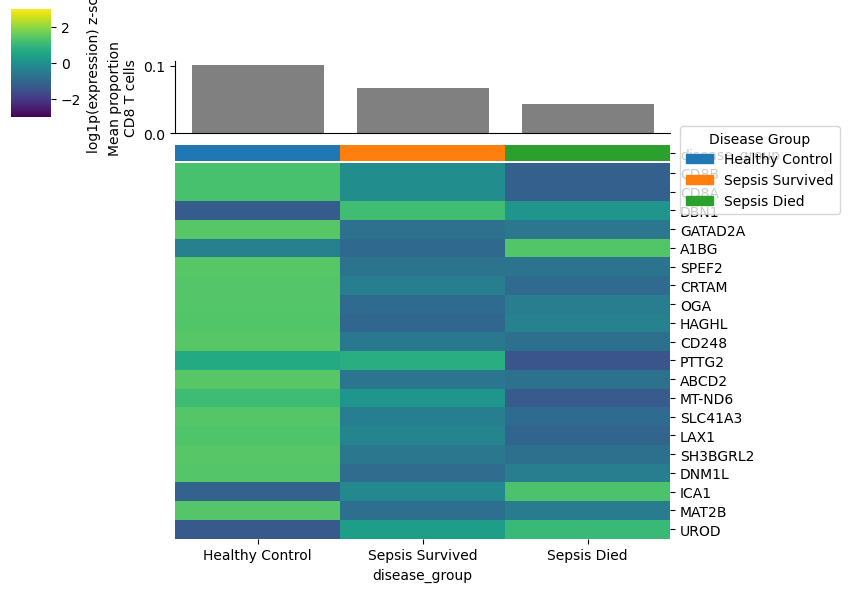

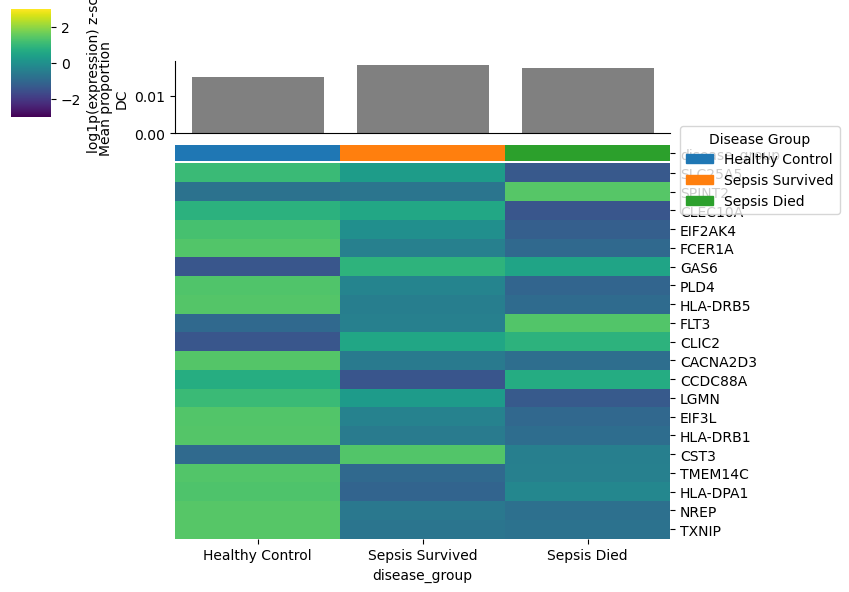

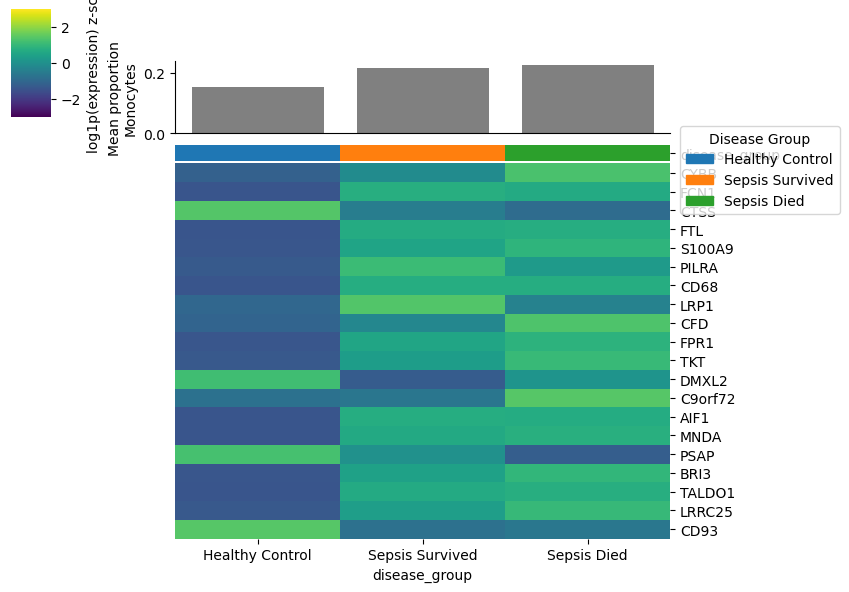

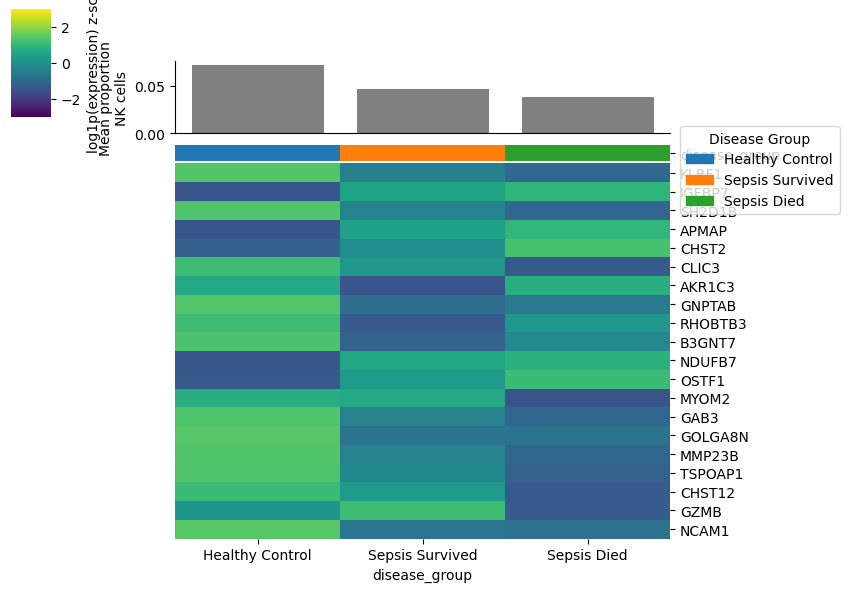

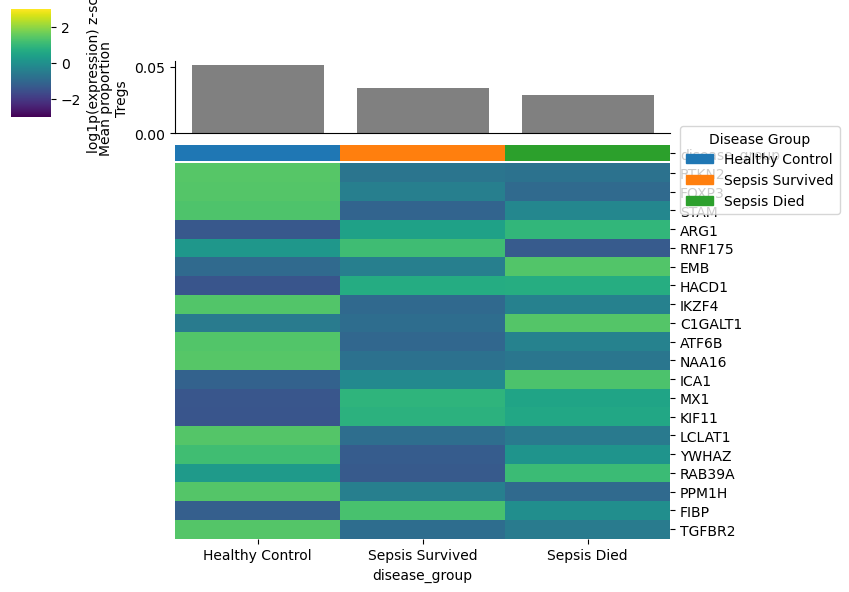

In [19]:
for cell_type in estimators:
    explain_heatmap_features(
        model_file, estimators, bulk_sorted, pred, cell_type, anno, indices,
        agg="mean",            # "mean" | "median" | "gmean"
        normalize="log1p_zscore",      # None | "log1p" | "zscore" | "log1p_zscore"
        plot_heatmap=True
    )

### New analysis

- Using raw proportions or CLR-normalized ones
- Using Mann Whitney U test & Kruskal Wallis test



In [20]:
# Relevant packages
from scipy.stats import mannwhitneyu, kruskal
from statsmodels.stats.multitest import multipletests

In [21]:
# CLR transformation

def clr_transform(df, celltypes, pseudocount=1e-6, renormalize=False):
    props = df[celltypes].copy().astype(float)

    if (props < 0).any().any():
        raise ValueError("Cell type proportions contain negative values.")

    props = props.replace(0, pseudocount)

    if renormalize: # means that props are rescaled to 1; as GrooD props not always sum to 1, this can distort the results, so I am using False as default
        row_sums = props.sum(axis=1)

        if (row_sums == 0).any():
            raise ValueError("At least one sample has all-zero cell type proportions.")

        props = props.div(row_sums, axis=0)

    log_props = np.log(props)
    clr = log_props.sub(log_props.mean(axis=1), axis=0)

    return clr

In [22]:
# Mannwhitney per pairwise comparison

def mannwhitney_by_celltype(
    df,
    celltypes,
    group_col,
    group_1,
    group_2,
    value_label="value"
):
    rows = []

    for ct in celltypes:
        x = df.loc[df[group_col] == group_1, ct].dropna()
        y = df.loc[df[group_col] == group_2, ct].dropna()

        if len(x) == 0 or len(y) == 0:
            rows.append({
                "celltype": ct,
                "comparison": f"{group_2} vs {group_1}",
                "group_1": group_1,
                "group_2": group_2,
                "n_group_1": len(x),
                "n_group_2": len(y),
                "median_group_1": np.nan,
                "median_group_2": np.nan,
                "median_difference": np.nan,
                "u_statistic": np.nan,
                "p_value": np.nan,
                "scale": value_label
            })
            continue

        test = mannwhitneyu(
            y,
            x,
            alternative="two-sided",
            method="auto"
        )

        rows.append({
            "celltype": ct,
            "comparison": f"{group_2} vs {group_1}",
            "group_1": group_1,
            "group_2": group_2,
            "n_group_1": len(x),
            "n_group_2": len(y),
            "median_group_1": np.median(x),
            "median_group_2": np.median(y),
            "median_difference": np.median(y) - np.median(x),
            "u_statistic": test.statistic,
            "p_value": test.pvalue,
            "scale": value_label
        })

    out = pd.DataFrame(rows)

    valid = out["p_value"].notna()

    out.loc[valid, "FDR"] = multipletests(
        out.loc[valid, "p_value"],
        alpha=0.05,
        method="fdr_bh"
    )[1]

    return out.sort_values("FDR")

# Pairwise Mannwhitney test across all disease groups

def pairwise_mannwhitney_all_groups(
    df,
    celltypes,
    group_col,
    group_levels,
    value_label="value",
    fdr_mode="all"
):
    """
    Pairwise Mann–Whitney U tests across all group pairs.

    fdr_mode:
        "all"     = correct across all cell type x contrast tests
        "within"  = correct separately within each contrast
        "both"    = return both corrections
    """

    all_results = []

    for i in range(len(group_levels)):
        for j in range(i + 1, len(group_levels)):
            g1 = group_levels[i]
            g2 = group_levels[j]

            res = mannwhitney_by_celltype(
                df=df,
                celltypes=celltypes,
                group_col=group_col,
                group_1=g1,
                group_2=g2,
                value_label=value_label
            )

            all_results.append(res)

    out = pd.concat(all_results, ignore_index=True)

    out = out.drop(columns=["FDR"], errors="ignore")

    valid = out["p_value"].notna()

    if fdr_mode in ["all", "both"]:
        out.loc[valid, "FDR_all_tests"] = multipletests(
            out.loc[valid, "p_value"],
            alpha=0.05,
            method="fdr_bh"
        )[1]

    if fdr_mode in ["within", "both"]:
        out["FDR_within_comparison"] = np.nan

        for comp in out["comparison"].unique():
            mask = (out["comparison"] == comp) & out["p_value"].notna()
            out.loc[mask, "FDR_within_comparison"] = multipletests(
                out.loc[mask, "p_value"],
                method="fdr_bh"
            )[1]

    return out.sort_values(
        [col for col in ["FDR_all_tests", "FDR_within_comparison", "p_value"] if col in out.columns]
    )

In [23]:
# Kruskal-Wallis

def kruskal_by_celltype(
    df,
    celltypes,
    group_col,
    group_levels,
    value_label="value"
):
    rows = []

    for ct in celltypes:
        values_by_group = [
            df.loc[df[group_col] == g, ct].dropna()
            for g in group_levels
        ]

        group_sizes = [len(v) for v in values_by_group]

        if any(n == 0 for n in group_sizes):
            rows.append({
                "celltype": ct,
                "h_statistic": np.nan,
                "p_value": np.nan,
                "scale": value_label,
                **{f"n_{g}": n for g, n in zip(group_levels, group_sizes)}
            })
            continue

        test = kruskal(*values_by_group)

        row = {
            "celltype": ct,
            "h_statistic": test.statistic,
            "p_value": test.pvalue,
            "scale": value_label
        }

        for g, vals in zip(group_levels, values_by_group):
            row[f"n_{g}"] = len(vals)
            row[f"median_{g}"] = np.median(vals)

        rows.append(row)

    out = pd.DataFrame(rows)

    valid = out["p_value"].notna()

    out.loc[valid, "FDR"] = multipletests(
        out.loc[valid, "p_value"],
        alpha=0.05,
        method="fdr_bh"
    )[1]

    return out.sort_values("FDR")

In [24]:
# Format predictions

celltypes = pred.columns.tolist()
pred['disease_group'] = anno.loc[pred.index.tolist(), 'disease_group']
pred

,B cells,CD4 T cells,CD8 T cells,DC,Monocytes,NK cells,Tregs,disease_group
GSM5609238,0.021858,0.150379,0.045417,0.009398,0.125937,0.043126,0.038134,Healthy Control
GSM5609334,0.072355,0.347783,0.064748,0.030755,0.260759,0.101801,0.058758,Healthy Control
GSM5609219,0.032436,0.137427,0.119684,0.021985,0.132971,0.044027,0.036564,Healthy Control
GSM5609245,0.065441,0.321514,0.227009,0.021999,0.185102,0.060845,0.033397,Healthy Control
GSM5609213,0.037557,0.101736,0.038850,0.007259,0.075908,0.069258,0.034207,Healthy Control
...,...,...,...,...,...,...,...,...
GSM5609298,0.042597,0.047385,0.016017,0.008042,0.300368,0.053215,0.022267,Sepsis Died
GSM5609114,0.010133,0.046002,0.023565,0.006194,0.151453,0.025792,0.026272,Sepsis Died
GSM5609322,0.037496,0.071949,0.035800,0.026001,0.359700,0.045701,0.016956,Sepsis Died
GSM5609076,0.004978,0.055703,0.215500,0.006930,0.249249,0.031785,0.027004,Sepsis Died


In [25]:
# CLR transform

clr_values = clr_transform(pred, celltypes, 1e-6)
clr_values['disease_group'] = pred.loc[clr_values.index.tolist(), 'disease_group']
clr_values

,B cells,CD4 T cells,CD8 T cells,DC,Monocytes,NK cells,Tregs,disease_group
GSM5609238,-0.686154,1.242427,0.045148,-1.530265,1.065052,-0.006595,-0.129614,Healthy Control
GSM5609334,-0.288374,1.281614,-0.399460,-1.143926,0.993632,0.053058,-0.496543,Healthy Control
GSM5609219,-0.599530,0.844297,0.706055,-0.988426,0.811333,-0.294003,-0.479727,Healthy Control
GSM5609245,-0.291404,1.300488,0.952438,-1.381565,0.748355,-0.364217,-0.964095,Healthy Control
GSM5609213,-0.086995,0.909522,-0.053148,-1.730572,0.616659,0.524976,-0.180443,Healthy Control
...,...,...,...,...,...,...,...,...
GSM5609298,0.144516,0.251047,-0.833628,-1.522601,2.097739,0.367068,-0.504141,Sepsis Died
GSM5609114,-0.922321,0.590598,-0.078340,-1.414485,1.782178,0.011980,0.030391,Sepsis Died
GSM5609322,-0.272100,0.379635,-0.318391,-0.638194,1.988944,-0.074209,-1.065684,Sepsis Died
GSM5609076,-1.996090,0.419002,1.771922,-1.665116,1.917412,-0.142058,-0.305072,Sepsis Died


In [26]:
# Run MannwhitneyUtest on CLR

group_levels = [
    "Healthy Control",
    "Sepsis Survived",
    "Sepsis Died"
]

mw_clr_all = pairwise_mannwhitney_all_groups(
    df=clr_values,
    celltypes=celltypes,
    group_col="disease_group",
    group_levels=group_levels,
    value_label="CLR",
    fdr_mode="both"
)

mw_clr_all

,celltype,comparison,group_1,group_2,n_group_1,n_group_2,median_group_1,median_group_2,median_difference,u_statistic,p_value,scale,FDR_all_tests,FDR_within_comparison
0,CD4 T cells,Sepsis Survived vs Healthy Control,Healthy Control,Sepsis Survived,44,293,1.353223,0.672468,-0.680755,821.0,1.021924e-20,CLR,2.146040e-19,7.153465e-20
1,Monocytes,Sepsis Survived vs Healthy Control,Healthy Control,Sepsis Survived,44,293,0.739126,1.675645,0.936519,11640.0,6.783013e-18,CLR,7.122163e-17,2.374054e-17
7,CD4 T cells,Sepsis Died vs Healthy Control,Healthy Control,Sepsis Died,44,52,1.353223,0.532639,-0.820584,28.0,2.354357e-16,CLR,1.648050e-15,1.648050e-15
8,Monocytes,Sepsis Died vs Healthy Control,Healthy Control,Sepsis Died,44,52,0.739126,1.867148,1.128021,2204.0,6.662737e-15,CLR,3.497937e-14,2.331958e-14
9,DC,Sepsis Died vs Healthy Control,Healthy Control,Sepsis Died,44,52,-1.666918,-1.176186,0.490732,1925.0,9.513749e-09,CLR,3.995775e-08,2.219875e-08
2,DC,Sepsis Survived vs Healthy Control,Healthy Control,Sepsis Survived,44,293,-1.666918,-1.207679,0.459239,9728.0,5.163543e-08,CLR,1.807240e-07,1.204827e-07
10,CD8 T cells,Sepsis Died vs Healthy Control,Healthy Control,Sepsis Died,44,52,0.271086,-0.301898,-0.572984,578.0,3.207116e-05,CLR,9.621349e-05,5.612453e-05
3,CD8 T cells,Sepsis Survived vs Healthy Control,Healthy Control,Sepsis Survived,44,293,0.271086,-0.215121,-0.486208,4238.0,2.489838e-04,CLR,6.535824e-04,4.357216e-04
4,B cells,Sepsis Survived vs Healthy Control,Healthy Control,Sepsis Survived,44,293,-0.292208,-0.611703,-0.319496,4291.0,3.497590e-04,CLR,8.161043e-04,4.896626e-04
14,CD4 T cells,Sepsis Died vs Sepsis Survived,Sepsis Survived,Sepsis Died,293,52,0.672468,0.532639,-0.139829,5575.0,2.058771e-03,CLR,4.323419e-03,1.441140e-02


In [27]:
# Run MannwhitneyUtest on raw proportions

mw_raw_all = pairwise_mannwhitney_all_groups(
    df=pred,
    celltypes=celltypes,
    group_col="disease_group",
    group_levels=group_levels,
    value_label="raw_proportion",
    fdr_mode="both"
)

mw_raw_all

,celltype,comparison,group_1,group_2,n_group_1,n_group_2,median_group_1,median_group_2,median_difference,u_statistic,p_value,scale,FDR_all_tests,FDR_within_comparison
0,CD4 T cells,Sepsis Survived vs Healthy Control,Healthy Control,Sepsis Survived,44,293,0.322329,0.069899,-0.252430,1195.0,2.956710e-18,raw_proportion,6.209090e-17,2.069697e-17
7,CD4 T cells,Sepsis Died vs Healthy Control,Healthy Control,Sepsis Died,44,52,0.322329,0.051449,-0.270880,99.0,1.585630e-14,raw_proportion,1.664912e-13,1.109941e-13
1,Tregs,Sepsis Survived vs Healthy Control,Healthy Control,Sepsis Survived,44,293,0.044399,0.028122,-0.016277,2341.0,9.669457e-12,raw_proportion,6.768620e-11,3.384310e-11
8,Tregs,Sepsis Died vs Healthy Control,Healthy Control,Sepsis Died,44,52,0.044399,0.026603,-0.017796,251.0,5.282125e-11,raw_proportion,2.773116e-10,1.848744e-10
10,B cells,Sepsis Died vs Healthy Control,Healthy Control,Sepsis Died,44,52,0.053672,0.017293,-0.036379,344.0,4.130308e-09,raw_proportion,1.734729e-08,9.426392e-09
9,CD8 T cells,Sepsis Died vs Healthy Control,Healthy Control,Sepsis Died,44,52,0.087890,0.022858,-0.065032,350.0,5.386510e-09,raw_proportion,1.885278e-08,9.426392e-09
11,NK cells,Sepsis Died vs Healthy Control,Healthy Control,Sepsis Died,44,52,0.068174,0.031185,-0.036990,367.0,1.131325e-08,raw_proportion,3.393976e-08,1.583855e-08
2,B cells,Sepsis Survived vs Healthy Control,Healthy Control,Sepsis Survived,44,293,0.053672,0.024480,-0.029191,3118.0,3.353124e-08,raw_proportion,8.801952e-08,7.823957e-08
3,NK cells,Sepsis Survived vs Healthy Control,Healthy Control,Sepsis Survived,44,293,0.068174,0.033962,-0.034213,3238.0,1.021914e-07,raw_proportion,2.384467e-07,1.788350e-07
4,CD8 T cells,Sepsis Survived vs Healthy Control,Healthy Control,Sepsis Survived,44,293,0.087890,0.029220,-0.058670,3294.0,1.696424e-07,raw_proportion,3.562490e-07,2.374993e-07


In [28]:
# Run Krsukal-Wallis Test on CLR

kw_clr_all = kruskal_by_celltype(
    clr_values,
    celltypes,
    'disease_group',
    group_levels,
    value_label="CLR"
)

kw_clr_all

,celltype,h_statistic,p_value,scale,n_Healthy Control,median_Healthy Control,n_Sepsis Survived,median_Sepsis Survived,n_Sepsis Died,median_Sepsis Died,FDR
1,CD4 T cells,100.332368,1.633440e-22,CLR,44,1.353223,293,0.672468,52,0.532639,1.143408e-21
4,Monocytes,82.827015,1.033575e-18,CLR,44,0.739126,293,1.675645,52,1.867148,3.617513e-18
3,DC,35.795220,1.687201e-08,CLR,44,-1.666918,293,-1.207679,52,-1.176186,3.936802e-08
2,CD8 T cells,18.495038,9.635039e-05,CLR,44,0.271086,293,-0.215121,52,-0.301898,1.686132e-04
0,B cells,13.638785,1.092384e-03,CLR,44,-0.292208,293,-0.611703,52,-0.660410,1.529338e-03
5,NK cells,3.622204,1.634739e-01,CLR,44,-0.003765,293,-0.087049,52,-0.027173,1.858473e-01
6,Tregs,3.365659,1.858473e-01,CLR,44,-0.345464,293,-0.194120,52,-0.111336,1.858473e-01


In [29]:
# Run Krsukal-Wallis Test on raw props

kw_raw_all = kruskal_by_celltype(
    pred,
    celltypes,
    'disease_group',
    group_levels,
    value_label="raw_proportion"
)

kw_raw_all

,celltype,h_statistic,p_value,scale,n_Healthy Control,median_Healthy Control,n_Sepsis Survived,median_Sepsis Survived,n_Sepsis Died,median_Sepsis Died,FDR
1,CD4 T cells,86.320063,1.802339e-19,raw_proportion,44,0.322329,293,0.069899,52,0.051449,1.261638e-18
6,Tregs,56.322254,5.885427e-13,raw_proportion,44,0.044399,293,0.028122,52,0.026603,2.059900e-12
0,B cells,36.891637,9.751757e-09,raw_proportion,44,0.053672,293,0.024480,52,0.017293,2.275410e-08
2,CD8 T cells,35.502013,1.953601e-08,raw_proportion,44,0.087890,293,0.029220,52,0.022858,3.418802e-08
5,NK cells,33.447421,5.457387e-08,raw_proportion,44,0.068174,293,0.033962,52,0.031185,7.640341e-08
4,Monocytes,21.213475,2.474870e-05,raw_proportion,44,0.147100,293,0.216035,52,0.211445,2.887348e-05
3,DC,3.935459,1.397738e-01,raw_proportion,44,0.014503,293,0.011379,52,0.009618,1.397738e-01


## Add results to boxplot of actual proportions

In [30]:

def format_pvalue(p):
    """
    Pretty p-value formatting.
    """
    if pd.isna(p):
        return "NA"
    elif p < 1e-4:
        return f"{p:.1e}"
    else:
        return f"{p:.4f}"


def props_with_separate_test(
    df,
    group_col,
    kw_results=None,
    mw_results=None,
    celltypes=None,
    group_order=None,
    fdr_col_kw="FDR",
    fdr_col_mw="FDR_all_tests",
    figsize_per_panel=(4, 4),
    ylabel="Inferred proportion",
    title_prefix="Predictions for",
    show_points=True,
    savepath=None
):
    """
    Plot original proportions as boxplots and annotate with CLR-based statistics.

    Parameters
    ----------
    df : pandas.DataFrame
        Dataframe containing original proportions and group labels.

    group_col : str
        Column containing group labels, e.g. "disease_group".

    kw_results : pandas.DataFrame, optional
        Kruskal-Wallis results from CLR-transformed data.
        Expected columns:
            celltype, p_value, FDR

    mw_results : pandas.DataFrame, optional
        Pairwise Mann-Whitney results from CLR-transformed data.
        Expected columns:
            celltype, comparison, p_value, FDR_all_tests or FDR_within_comparison

    celltypes : list[str], optional
        Cell type columns to plot.
        If None, all columns except group_col are used.

    group_order : list[str], optional
        Order of groups on x-axis.

    fdr_col_kw : str
        FDR column to use for Kruskal-Wallis annotation.

    fdr_col_mw : str
        FDR column to use for Mann-Whitney annotation.

    figsize_per_panel : tuple
        Width and height per subplot.

    ylabel : str
        Y-axis label.

    title_prefix : str
        Prefix for subplot titles.

    show_points : bool
        Whether to overlay individual samples.

    savepath : str, optional
        If provided, saves the figure to this path.

    Returns
    -------
    fig, axes
    """

    df = df.copy()

    if celltypes is None:
        celltypes = df.drop(columns=[group_col]).columns.tolist()

    # Keep only numeric cell type columns
    celltypes = [
        ct for ct in celltypes
        if pd.api.types.is_numeric_dtype(df[ct])
    ]

    n = len(celltypes)

    if n == 0:
        raise ValueError("No numeric cell type columns found to plot.")

    rows = math.floor(math.sqrt(n))
    rows = max(rows, 1)
    cols = math.ceil(n / rows)

    fig, axes = plt.subplots(
        rows,
        cols,
        figsize=(cols * figsize_per_panel[0], rows * figsize_per_panel[1])
    )

    axes = np.array(axes).flatten()

    for i, celltype in enumerate(celltypes):
        ax = axes[i]

        df_plot = df[[group_col, celltype]].copy()
        df_plot["SampleID"] = df_plot.index.astype(str)
        df_plot = df_plot.rename(columns={celltype: "value"})

        sns.boxplot(
            data=df_plot,
            x=group_col,
            y="value",
            hue=group_col,
            order=group_order,
            hue_order=group_order,
            ax=ax,
            dodge=False,
            showfliers=False
        )

        if show_points:
            sns.stripplot(
                data=df_plot,
                x=group_col,
                y="value",
                order=group_order,
                ax=ax,
                dodge=False,
                color="black",
                alpha=0.5,
                size=3
            )

        # Remove duplicate legend
        legend = ax.get_legend()
        if legend is not None:
            legend.remove()

        ax.set_xticklabels(
            ax.get_xticklabels(),
            rotation=45,
            horizontalalignment="right"
        )

        ax.set_title(f"{title_prefix} {celltype}")
        ax.set_xlabel("")
        ax.set_ylabel(ylabel)

        annotation_lines = []

        # Add Kruskal-Wallis result
        if kw_results is not None:
            kw_row = kw_results.loc[
                kw_results["celltype"].astype(str) == str(celltype)
            ]

            if len(kw_row) > 0:
                kw_row = kw_row.iloc[0]

                kw_p = kw_row.get("p_value", np.nan)
                kw_fdr = kw_row.get(fdr_col_kw, np.nan)

                annotation_lines.append(
                    f"CLR KW: p={format_pvalue(kw_p)}, FDR={format_pvalue(kw_fdr)}"
                )

        # Add Mann-Whitney pairwise results
        if mw_results is not None:
            mw_rows = mw_results.loc[
                mw_results["celltype"].astype(str) == str(celltype)
            ].copy()

            if len(mw_rows) > 0:
                # Sort pairwise comparisons by p-value or FDR if available
                sort_col = fdr_col_mw if fdr_col_mw in mw_rows.columns else "p_value"
                mw_rows = mw_rows.sort_values(sort_col)

                for _, row in mw_rows.iterrows():
                    comparison = row.get("comparison", "comparison")
                    pval = row.get("p_value", np.nan)
                    fdr = row.get(fdr_col_mw, np.nan)

                    annotation_lines.append(
                        f"CLR MW {comparison}: p={format_pvalue(pval)}, FDR={format_pvalue(fdr)}"
                    )

        if len(annotation_lines) > 0:
            annotation_text = "\n".join(annotation_lines)

            ax.text(
                0.02,
                0.98,
                annotation_text,
                transform=ax.transAxes,
                verticalalignment="top",
                horizontalalignment="left",
                fontsize=8,
                bbox=dict(
                    boxstyle="round",
                    facecolor="white",
                    alpha=0.8,
                    edgecolor="gray"
                )
            )

    for j in range(n, len(axes)):
        fig.delaxes(axes[j])

    fig.suptitle(f"Original proportions by {group_col}", y=1.02)

    plt.tight_layout()

    if savepath is not None:
        plt.savefig(savepath, dpi=300, bbox_inches="tight")

    return fig, axes

(<Figure size 1600x800 with 7 Axes>,
 array([<Axes: title={'center': 'Predictions for B cells'}, ylabel='Inferred proportion'>,
        <Axes: title={'center': 'Predictions for CD4 T cells'}, ylabel='Inferred proportion'>,
        <Axes: title={'center': 'Predictions for CD8 T cells'}, ylabel='Inferred proportion'>,
        <Axes: title={'center': 'Predictions for DC'}, ylabel='Inferred proportion'>,
        <Axes: title={'center': 'Predictions for Monocytes'}, ylabel='Inferred proportion'>,
        <Axes: title={'center': 'Predictions for NK cells'}, ylabel='Inferred proportion'>,
        <Axes: title={'center': 'Predictions for Tregs'}, ylabel='Inferred proportion'>,
        <Axes: >], dtype=object))

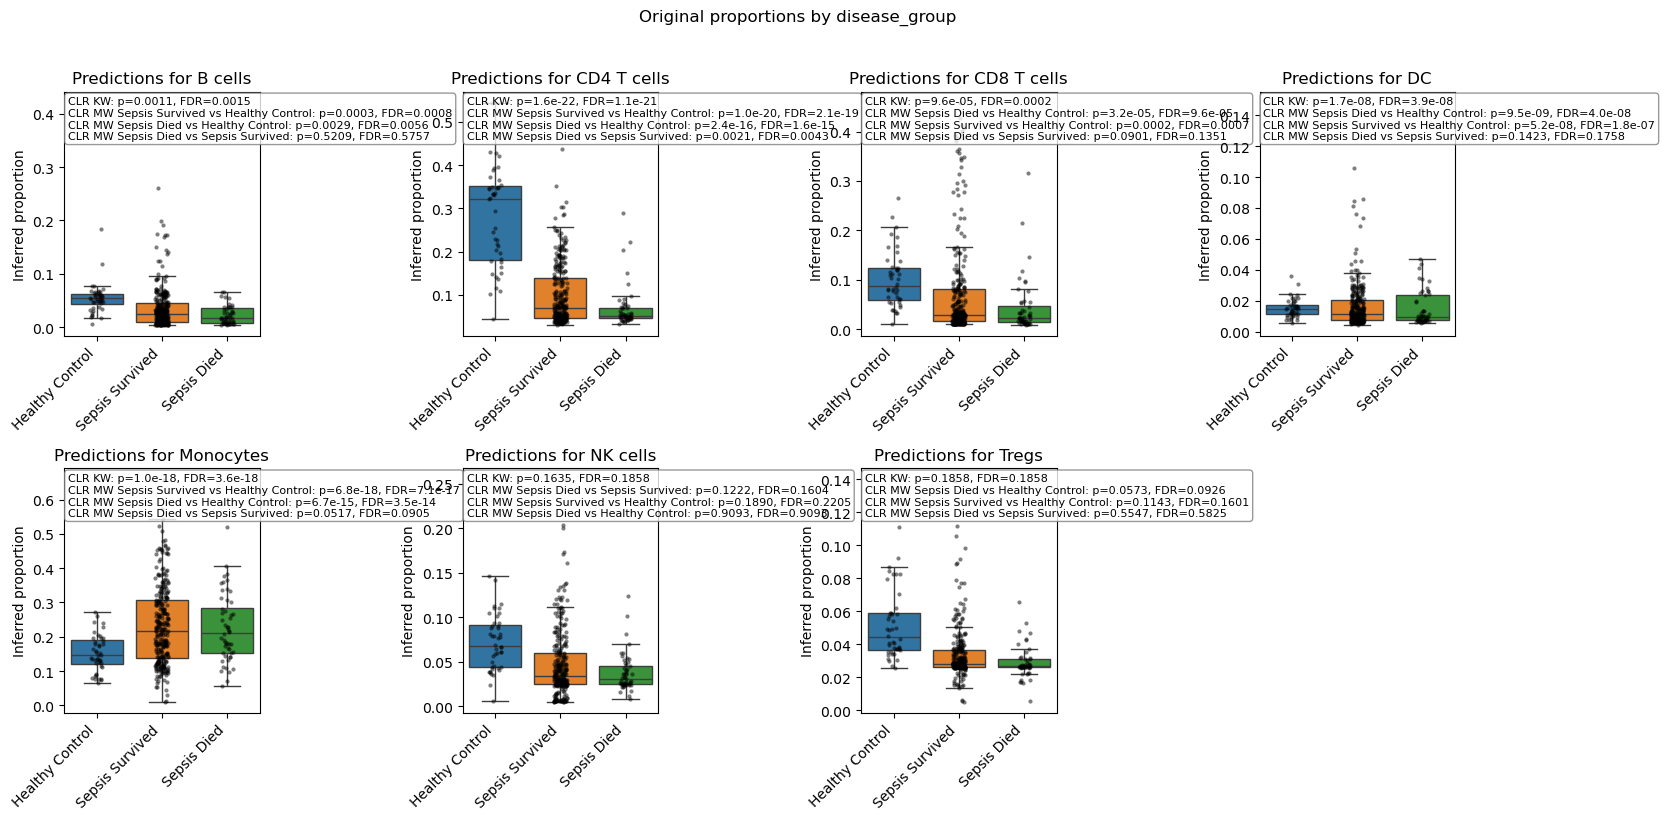

In [31]:
props_with_separate_test(pred, 'disease_group', kw_clr_all, mw_clr_all, celltypes, group_order=['Healthy Control', 'Sepsis Survived', 'Sepsis Died'])

(<Figure size 1600x800 with 7 Axes>,
 array([<Axes: title={'center': 'Predictions for B cells'}, ylabel='Inferred proportion'>,
        <Axes: title={'center': 'Predictions for CD4 T cells'}, ylabel='Inferred proportion'>,
        <Axes: title={'center': 'Predictions for CD8 T cells'}, ylabel='Inferred proportion'>,
        <Axes: title={'center': 'Predictions for DC'}, ylabel='Inferred proportion'>,
        <Axes: title={'center': 'Predictions for Monocytes'}, ylabel='Inferred proportion'>,
        <Axes: title={'center': 'Predictions for NK cells'}, ylabel='Inferred proportion'>,
        <Axes: title={'center': 'Predictions for Tregs'}, ylabel='Inferred proportion'>,
        <Axes: >], dtype=object))

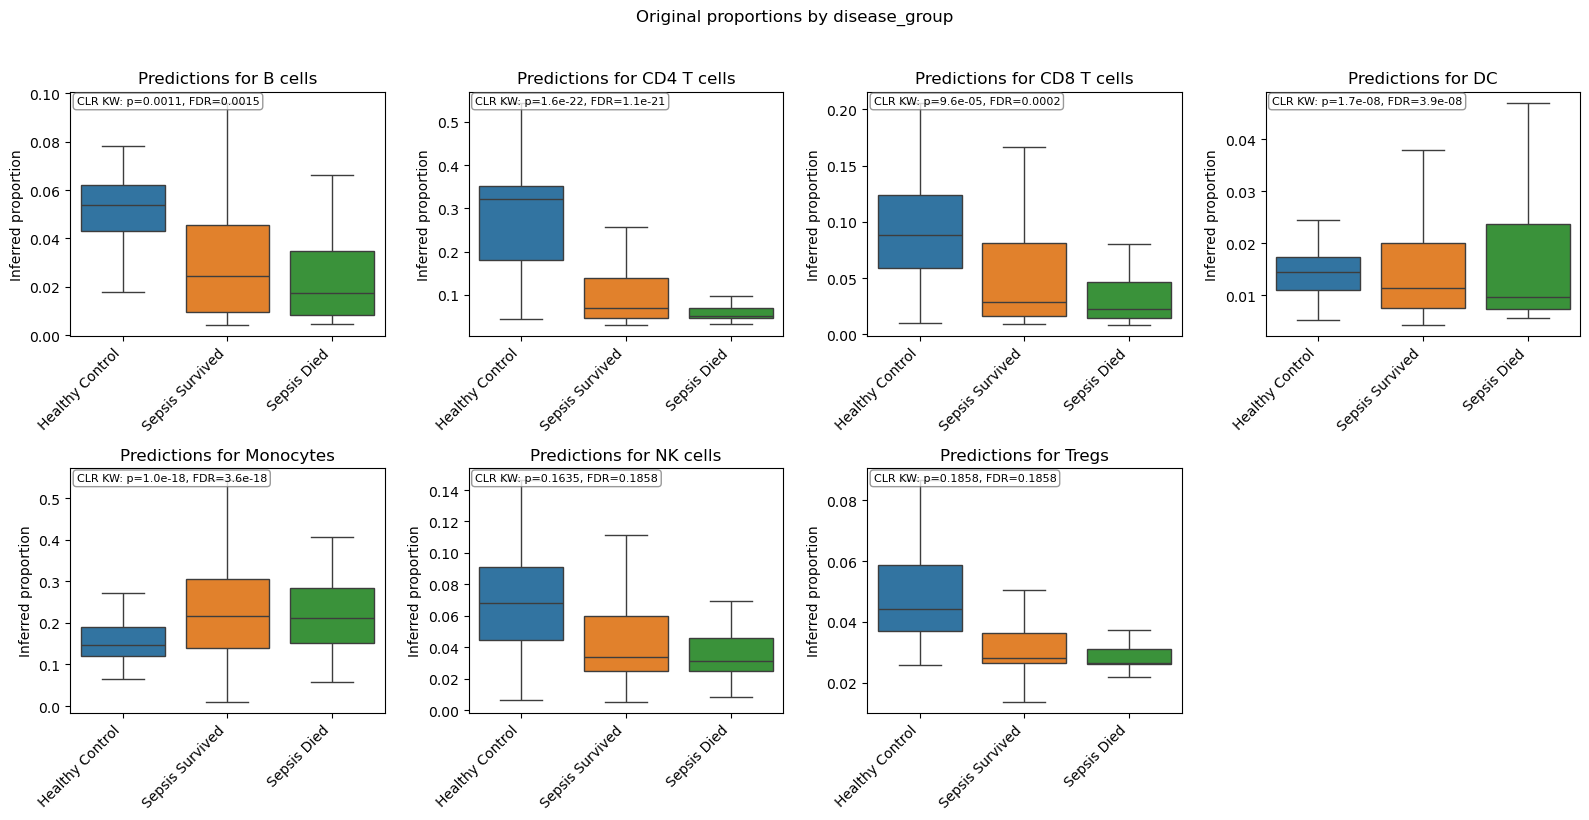

In [32]:
props_with_separate_test(df=pred, group_col='disease_group', kw_results=kw_clr_all, mw_results=None, celltypes=celltypes, group_order=['Healthy Control', 'Sepsis Survived', 'Sepsis Died'], show_points=False)

In [33]:
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


def p_to_stars(p):
    if pd.isna(p):
        return "NA"
    elif p < 0.0001:
        return "****"
    elif p < 0.001:
        return "***"
    elif p < 0.01:
        return "**"
    elif p < 0.05:
        return "*"
    else:
        return "ns"


def format_pvalue(p):
    if pd.isna(p):
        return "NA"
    elif p < 1e-4:
        return f"{p:.1e}"
    else:
        return f"{p:.4f}"


def add_sig_bracket(
    ax,
    x1,
    x2,
    y,
    h,
    text,
    fontsize=9,
    linewidth=1.2
):
    """
    Add a bracket with text between x1 and x2 at height y.
    """
    ax.plot(
        [x1, x1, x2, x2],
        [y, y + h, y + h, y],
        lw=linewidth,
        color="black"
    )

    ax.text(
        (x1 + x2) / 2,
        y + h,
        text,
        ha="center",
        va="bottom",
        fontsize=fontsize
    )

def props_with_sig_brackets(
    df,
    group_col,
    mw_results,
    kw_results=None,
    celltypes=None,
    group_order=None,
    stat_col="FDR_all_tests",
    show_ns=False,
    max_annotations=None,
    annotation_format="stars",
    figsize_per_panel=(4, 4),
    ylabel="Inferred proportion",
    title_prefix="Predictions for",
    show_points=True,
    savepath=None
):
    """
    Plot original proportions and annotate pairwise CLR-based Mann-Whitney
    significance using bracket lines.

    Parameters
    ----------
    df : pandas.DataFrame
        Dataframe containing original proportions and group labels.

    group_col : str
        Group column, e.g. "disease_group".

    mw_results : pandas.DataFrame
        Pairwise Mann-Whitney results computed on CLR values.
        Expected columns include:
            celltype, group_1, group_2, comparison, p_value,
            FDR_all_tests and/or FDR_within_comparison.

        Brackets are drawn between group_1 and group_2.

    kw_results : pandas.DataFrame, optional
        Kruskal-Wallis results computed on CLR values.
        Expected columns:
            celltype, p_value, FDR

    celltypes : list[str], optional
        Cell type columns to plot.
        If None, all numeric columns except group_col are used.

    group_order : list[str], optional
        Order of groups on x-axis.

    stat_col : str
        Column used for significance annotation.
        Common choices:
            "p_value"
            "FDR_all_tests"
            "FDR_within_comparison"

    show_ns : bool
        Whether to annotate non-significant comparisons.

    max_annotations : int, optional
        Maximum number of pairwise brackets per panel.
        Useful to avoid overcrowding.

    annotation_format : str
        "stars" gives *, **, ***.
        "pvalue" gives q=0.0123 / p=0.0123.
        "both" gives * plus q-value.

    figsize_per_panel : tuple
        Width and height per subplot.

    ylabel : str
        Y-axis label.

    title_prefix : str
        Prefix for subplot titles.

    show_points : bool
        Whether to overlay individual points.

    savepath : str, optional
        Save figure path.

    Returns
    -------
    fig, axes
    """

    df = df.copy()

    if group_order is None:
        group_order = list(pd.unique(df[group_col].dropna()))

    group_to_x = {g: i for i, g in enumerate(group_order)}

    if celltypes is None:
        celltypes = [
            c for c in df.columns
            if c != group_col and pd.api.types.is_numeric_dtype(df[c])
        ]

    n = len(celltypes)

    if n == 0:
        raise ValueError("No numeric cell type columns found to plot.")

    rows = math.floor(math.sqrt(n))
    rows = max(rows, 1)
    cols = math.ceil(n / rows)

    fig, axes = plt.subplots(
        rows,
        cols,
        figsize=(cols * figsize_per_panel[0], rows * figsize_per_panel[1])
    )

    axes = np.array(axes).flatten()

    for i, celltype in enumerate(celltypes):
        ax = axes[i]

        df_plot = df[[group_col, celltype]].copy()
        df_plot = df_plot.rename(columns={celltype: "value"})

        sns.boxplot(
            data=df_plot,
            x=group_col,
            y="value",
            hue=group_col,
            order=group_order,
            hue_order=group_order,
            ax=ax,
            dodge=False,
            showfliers=False
        )

        if show_points:
            sns.stripplot(
                data=df_plot,
                x=group_col,
                y="value",
                order=group_order,
                ax=ax,
                dodge=False,
                color="black",
                alpha=0.5,
                size=3
            )

        legend = ax.get_legend()
        if legend is not None:
            legend.remove()

        ax.set_xticklabels(
            ax.get_xticklabels(),
            rotation=45,
            horizontalalignment="right"
        )

        title = f"{title_prefix} {celltype}"

        if kw_results is not None:
            kw_row = kw_results.loc[
                kw_results["celltype"].astype(str) == str(celltype)
            ]

            if len(kw_row) > 0:
                kw_fdr = kw_row.iloc[0].get("FDR", np.nan)
                title += f"\nCLR KW FDR={format_pvalue(kw_fdr)}"

        ax.set_title(title)
        ax.set_xlabel("")
        ax.set_ylabel(ylabel)

        # Pairwise annotations for this cell type
        mw_rows = mw_results.loc[
            mw_results["celltype"].astype(str) == str(celltype)
        ].copy()

        if len(mw_rows) > 0:
            if stat_col not in mw_rows.columns:
                raise ValueError(
                    f"'{stat_col}' not found in mw_results. "
                    f"Available columns: {list(mw_rows.columns)}"
                )

            # Keep only comparisons where both groups are in the plot
            mw_rows = mw_rows[
                mw_rows["group_1"].isin(group_order) &
                mw_rows["group_2"].isin(group_order)
            ].copy()

            # Optionally hide non-significant comparisons
            if not show_ns:
                mw_rows = mw_rows[mw_rows[stat_col] < 0.05].copy()

            # Sort by significance so strongest annotations are closest to boxes
            mw_rows = mw_rows.sort_values(stat_col)

            if max_annotations is not None:
                mw_rows = mw_rows.head(max_annotations)

            if len(mw_rows) > 0:
                y_min = df_plot["value"].min()
                y_max = df_plot["value"].max()
                y_range = y_max - y_min

                if y_range == 0:
                    y_range = max(abs(y_max), 1e-6)

                base_y = y_max + 0.08 * y_range
                step = 0.12 * y_range
                bracket_h = 0.04 * y_range

                for k, (_, row) in enumerate(mw_rows.iterrows()):
                    g1 = row["group_1"]
                    g2 = row["group_2"]

                    x1 = group_to_x[g1]
                    x2 = group_to_x[g2]

                    stat_value = row[stat_col]

                    if annotation_format == "stars":
                        text = p_to_stars(stat_value)
                    elif annotation_format == "pvalue":
                        label = "q" if "FDR" in stat_col else "p"
                        text = f"{label}={format_pvalue(stat_value)}"
                    elif annotation_format == "both":
                        label = "q" if "FDR" in stat_col else "p"
                        text = f"{p_to_stars(stat_value)}\n{label}={format_pvalue(stat_value)}"
                    else:
                        raise ValueError(
                            "annotation_format must be one of: "
                            "'stars', 'pvalue', 'both'"
                        )

                    y = base_y + k * step

                    add_sig_bracket(
                        ax=ax,
                        x1=x1,
                        x2=x2,
                        y=y,
                        h=bracket_h,
                        text=text
                    )

                # Expand y-axis to fit annotations
                new_ymax = base_y + len(mw_rows) * step + bracket_h
                ax.set_ylim(y_min, new_ymax)

    for j in range(n, len(axes)):
        fig.delaxes(axes[j])

    fig.suptitle(
        f"Original proportions with CLR-based Mann-Whitney annotations",
        y=1.02
    )

    plt.tight_layout()

    if savepath is not None:
        plt.savefig(savepath, dpi=300, bbox_inches="tight")

    return fig, axes

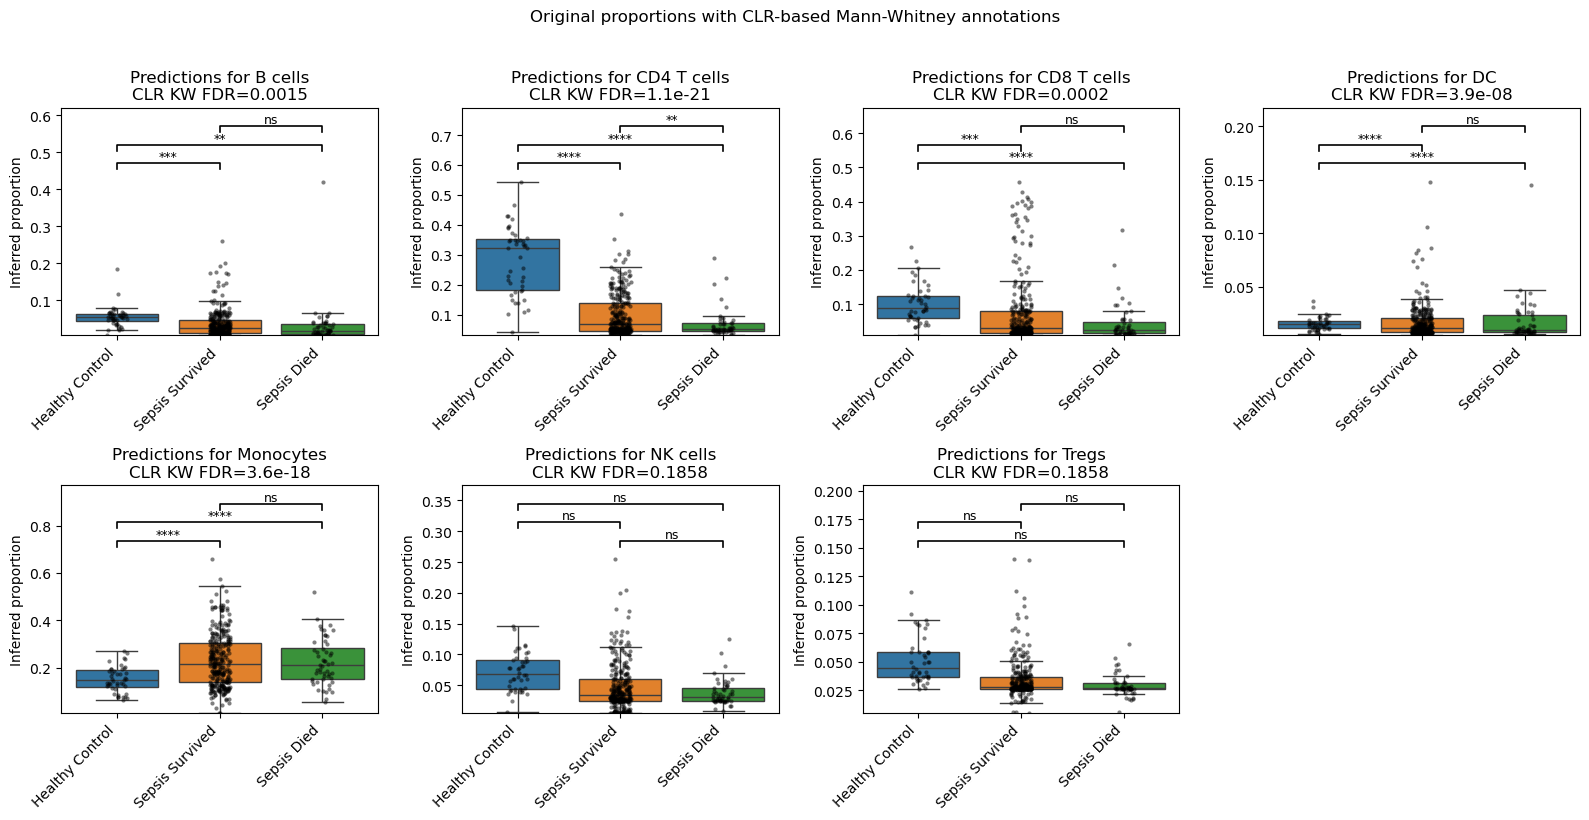

In [34]:
fig, axes = props_with_sig_brackets(
    df=pred,
    group_col="disease_group",
    mw_results=mw_clr_all,
    kw_results=kw_clr_all,
    group_order=["Healthy Control", "Sepsis Survived", "Sepsis Died"],
    stat_col="FDR_all_tests",
    show_ns=True,
    annotation_format="stars",
    ylabel="Inferred proportion",
    savepath="Figure_3A_new_boxplot.svg"
)